In [1]:
from unet import *
import tensorflow as tf 

In [2]:
# List physical GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPUs detected: {gpus}")
    try:
        # Enable memory growth on all GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPU(s).")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print("Error setting memory growth:", e)
else:
    print("No GPU detected; running on CPU.")

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled for GPU(s).


In [3]:
def compute_snow_ratio(mask_path):
    """Compute the ratio of snow pixels (value = 1) in the mask."""
    mask = np.load(mask_path)
    snow_ratio = np.mean(mask)  # Fraction of pixels that are snow
    return snow_ratio

def find_all_tile_pairs(allowed_sites, folder_path, max_per_site, mid_low_high_ratio_distribution=(0.8, 0.1, 0.1), snow_vs_notsnow_ratio_distribution=(.8, .2)):
    """
    Find and return tile pairs with a balanced snow vs no-snow distribution.
    
    Parameters:
        allowed_sites (list): List of allowed sites.
        folder_path (str): Path where image and mask tiles are stored.
        max_per_site (int): Max tile pairs per site.
        mid_low_high_ratio_distribution (tuple): (mid-range %, low-snow %, high-snow %), should sum to 1.
        
    Returns:
        list: A list of selected (image, mask) tile pairs.
    """
    img_paths = glob.glob(os.path.join(folder_path, "*_img.npy"))
    
    # Group pairs by site
    site_to_pairs = {site: [] for site in allowed_sites}
    for ip in img_paths:
        site = get_site_from_tile(ip)
        if site in allowed_sites:
            mp = ip.replace("_img.npy", "_msk.npy")
            if os.path.exists(mp):
                site_to_pairs[site].append((ip, mp))

    # Store tiles based on snow ratio categories
    balanced_pairs = []

    sampled_low_count = 0
    sampled_mid_count = 0
    sampled_high_count = 0

    p_high = snow_vs_notsnow_ratio_distribution[0]
    p_low = snow_vs_notsnow_ratio_distribution[1]
    
    for site, pairs_list in site_to_pairs.items():
        if not pairs_list:
            continue
        print("\n" + site + ": " )
        # Compute snow ratios for each tile pair
        pairs_with_ratios = [(img, msk, compute_snow_ratio(msk)) for img, msk in pairs_list]
        print(f"Num of pairs: {len(pairs_with_ratios)}")
        
        # Sort into categories
        mid_range = [(img, msk) for img, msk, ratio in pairs_with_ratios if p_low <= ratio <= p_high]
        print(f"Num of pairs with {p_low*100}% to {p_high*100}% snow pixels: {len(mid_range)}")
        low_snow = [(img, msk) for img, msk, ratio in pairs_with_ratios if ratio < p_low]
        print(f"Num of pairs with {p_low*100}% or less snow pixels: {len(low_snow)}")
        high_snow = [(img, msk) for img, msk, ratio in pairs_with_ratios if ratio > p_high]
        print(f"Num of pairs with {p_high*100}% or more snow pixels: {len(high_snow)}")

        mid_percentage = mid_low_high_ratio_distribution[0]
        low_percentage = mid_low_high_ratio_distribution[1]
        high_percentage = mid_low_high_ratio_distribution[2]

        # Sample according to specified ratios
        n_mid = int(max_per_site * mid_percentage)
        n_low = int(max_per_site * low_percentage)
        n_high = int(max_per_site * high_percentage)

        number_mid_range_tiles = len(mid_range)

        if number_mid_range_tiles < n_mid:
            n_low = int(number_mid_range_tiles * (low_percentage/mid_percentage))
            n_high = int(number_mid_range_tiles * (high_percentage/mid_percentage))

        sampled_mid = random.sample(mid_range, min(len(mid_range), n_mid))
        sampled_low = random.sample(low_snow, min(len(low_snow), n_low))
        sampled_high = random.sample(high_snow, min(len(high_snow), n_high))
        
        # Combine sampled pairs
        site_sampled_pairs = sampled_mid + sampled_low + sampled_high
        sampled_low_count += len(sampled_low)
        sampled_mid_count += len(sampled_mid)
        sampled_high_count += len(sampled_high)
        balanced_pairs.extend(site_sampled_pairs)

    # Shuffle final list for randomness
    random.shuffle(balanced_pairs)
    print("Total tiles breakdown")
    print(f"Number of pairs with {p_low*100}% to {p_high*100}% snow pixels: {sampled_mid_count}") 
    print(f"Number of pairs with {p_low*100}% or less snow pixels: {sampled_low_count}") 
    print(f"Number of pairs with {p_high*100}% or more snow pixels: {sampled_high_count}")
    print(f"Selected {len(balanced_pairs)} valid (img, msk) pairs")
    
    return balanced_pairs

In [4]:
def run_unet_training(
    folder_path,             # path to the folder containing your tiled output
    training_sites,          # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites,        # list of site names for in-distribution validation
    testing_sites,           # list of site names for testing (unseen sites)
    max_tiles_per_training_sites,            # maximum number of training tile pairs per site
    max_tiles_per_validation_sites,          # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites,             # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution,
    img_height,              # image height (e.g., 512)
    img_width,               # image width (e.g., 512)
    img_channels,            # number of image channels (e.g., 4)
    batch_size,              # training batch size (e.g., 32)
    epochs,                  # number of training epochs (e.g., 20)
    comet_api_key,           # your Comet.ml API key
    comet_project_name,      # your Comet.ml project name, e.g. "unet-snow-model"
    comet_workspace,         # your Comet.ml workspace, e.g. "reversedpuppy"
    model_instance_name=None # optional: name for the experiment in Comet.ml
):
    """
    Runs the full U-Net training pipeline and logs additional custom parameters
    to Comet.ml.
    """
    # Create a Comet.ml experiment and set a custom name if provided.
    from comet_ml import Experiment
    experiment = Experiment(
        api_key=comet_api_key,
        project_name=comet_project_name,
        workspace=comet_workspace
    )
    if model_instance_name is not None:
        experiment.set_name(model_instance_name)
    
    # Get tile pairs for each split.
    print("---------Training Tiles---------")
    train_pairs = find_all_tile_pairs(training_sites, folder_path, max_tiles_per_training_sites, mid_low_high_ratio_distribution, snow_vs_notsnow_ratio_distribution)
    print("\n---------Validation Tiles---------")
    val_pairs   = find_all_tile_pairs(validation_sites, folder_path, max_tiles_per_validation_sites, mid_low_high_ratio_distribution, snow_vs_notsnow_ratio_distribution)
    print("\n---------Testing Tiles---------")
    test_pairs  = find_all_tile_pairs(testing_sites, folder_path, max_tiles_per_testing_sites, mid_low_high_ratio_distribution, snow_vs_notsnow_ratio_distribution)
    
    print(f"\nTrain: {len(train_pairs)} pairs, Val: {len(val_pairs)} pairs, Test: {len(test_pairs)} pairs\n")
    
    # Create TensorFlow datasets (assumes make_dataset is defined)
    train_dataset = make_dataset(train_pairs, batch_size=batch_size, shuffle=True, valid_threshold=1.0)
    val_dataset   = make_dataset(val_pairs, batch_size=batch_size, shuffle=False, valid_threshold=1.0)
    test_dataset  = make_dataset(test_pairs, batch_size=batch_size, shuffle=False, valid_threshold=1.0)
    
    # Build the U-Net model (assumes unet_model is defined)
    my_unet = unet_model(n_classes=1, img_height=img_height, img_width=img_width, img_channels=img_channels)
    
    # Prepare metadata for logging
    import datetime
    date_str = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M")
    dataset_info = {
        "training_sites": training_sites,
        "validation_sites": validation_sites,
        "testing_sites": testing_sites,
        "folder_path": folder_path,
        "num_train_samples": len(train_pairs),
        "num_val_samples": len(val_pairs),
        "num_test_samples": len(test_pairs),
        "image_shape": (img_height, img_width, img_channels)
    }
    
    # Log all training parameters to Comet.ml.
    experiment.log_parameters({
        "batch_size": batch_size,
        "epochs": epochs,
        "img_height": img_height,
        "img_width": img_width,
        "img_channels": img_channels,
        "training_sites": ", ".join(training_sites),
        "validation_sites": ", ".join(validation_sites),
        "testing_sites": ", ".join(testing_sites),
        "max_tiles_per_training_site": max_tiles_per_training_sites,
        "max_tiles_per_validation_site": max_tiles_per_validation_sites,
        "max_tiles_per_testing_site": max_tiles_per_testing_sites,
        "mid_low_high_ratio_distribution": mid_low_high_ratio_distribution,
        "snow_vs_notsnow_ratio_distribution": snow_vs_notsnow_ratio_distribution
    })
    
    # Train the model (assumes train_model is defined)
    model, history = train_model(
        unet_model=my_unet,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        date_str=date_str,
        dataset_info=dataset_info,
        batch_size=batch_size,
        epochs=epochs,
        experiment=experiment,
        instance_name=model_instance_name
    )
    
    # Evaluate the model on the test dataset
    import math
    num_test_samples = len(test_pairs)
    steps_for_test = math.ceil(num_test_samples / batch_size)
    eval_results = model.evaluate(test_dataset, steps=steps_for_test, return_dict=True)
    
    metrics_dict = {
        "test_loss": eval_results.get("loss", None),
        "test_accuracy": eval_results.get("accuracy", None),
        "test_precision": eval_results.get("precision", None),
        "test_recall": eval_results.get("recall", None),
        "test_dice_coef": eval_results.get("dice_coef", None)
    }
    experiment.log_metrics(metrics_dict)
    experiment.end()
    
    return model, history, eval_results


In [5]:
folder_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output"

comet_api_key="HMIpeLQjlVPMeWB9fDhY9Pv11"
comet_project_name="unet-snow-model"
comet_workspace="reversedpuppy"

IMG_HEIGHT = 512
IMG_WIDTH = 512
IMG_CHANNELS = 4

Hyperparameters:
Mid_low_high ratio distribution
snow vs not snow ratio 
tile size
tile overlap
loss function 
sites used for training,validation, and testing
epochs
architecture: Layers and Activation functions


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/fcd8eb14104743599659c7c95bf1c245



---------Training Tiles---------

DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 1383
Number of pairs with 20.0% or less snow pixels: 691
Number of pairs with 80.0% or more snow pixels: 691
Selected 2765 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 1574
Number of pairs with 20.0% or less snow pixels: 787
Number of pairs with 80.0% or more snow pixels: 787
Selected 3148 valid (img, msk) pairs

---------Testing Tiles---------

VirginiaBasin: 
Num of pairs: 6023
Num of pairs with 20.0% to 80.0% snow pixels: 260
Num

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 512, 512, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 512, 512, 16)      │             576 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 512, 512, 16)      │              64 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 512, 512, 16)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 512, 512, 16)      │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 512, 512, 16)      │           2,304 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 512, 512, 16)      │              64 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 512, 512, 16)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 256, 256, 16)      │               0 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 256, 256, 32)      │           4,608 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 256, 256, 32)      │             128 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 256, 256, 32)      │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 256, 256, 32)      │               0 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 256, 256, 32)      │           9,216 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 256, 256, 32)      │             128 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 34,622,785 (132.08 MB)

...

 Non-trainable params: 12,160 (47.50 KB)

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Training with batch size: 32
Number of epochs: 20
Steps per epoch (auto): 43
Epoch 1/20
Batch 0: loss = 47.2463
Batch 1: loss = 44.4802━━━━━━━━━━━━━━━━ 16:33 24s/step - accuracy: 0.5970 - dice_coef: 0.2761 - loss: 47.2463 - precision: 0.0238 - recall: 0.0028
Batch 2: loss = 41.8391━━━━━━━━━━━━━━━━ 7:45 11s/step - accuracy: 0.6205 - dice_coef: 0.3106 - loss: 45.8632 - precision: 0.2242 - recall: 0.0288 
Batch 3: loss = 39.3373m━━━━━━━━━━━━━━━━━━━ 7:28 11s/step - accuracy: 0.6586 - dice_coef: 0.3428 - loss: 44.5219 - precision: 0.4236 - recall: 0.1135
Batch 4: loss = 36.9713m━━━━━━━━━━━━━━━━━━━ 7:12 11s/step - accuracy: 0.6914 - dice_coef: 0.3728 - loss: 43.2257 - precision: 0.5426 - recall: 0.1972
Batch 5: loss = 34.77590m━━━━━━━━━━━━━━━━━━ 6:59 11s/step - accuracy: 0.7180 - dice_coef: 0.3990 - loss: 41.9748 - precision: 0.6177 - recall: 0.2650
Batch 6: loss = 32.69990m━━━━━━━━━━━━━━━━━━ 6:47 11s/step - accuracy: 0.7379 - dice_coef: 0.4220 - loss: 40.7750 - precision: 0.6714 - recall: 0

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\tensor_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 1.90244, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000979
43/43 ━━━━━━━━━━━━━━━━━━━━ 510s 12s/step - accuracy: 0.9009 - dice_coef: 0.6718 - loss: 19.4739 - precision: 0.9084 - recall: 0.7819 - val_accuracy: 0.3135 - val_dice_coef: 0.4220 - val_loss: 1.9024 - val_precision: 0.3135 - val_recall: 1.0000
Epoch 2/20
Batch 0: loss = 1.1739
Batch 1: loss = 1.1341━━━━━━━━━━━━━━━━━ 8:52 13s/step - accuracy: 0.9586 - dice_coef: 0.8240 - loss: 1.1739 - precision: 0.8921 - recall: 0.9973
Batch 2: loss = 1.0964━━━━━━━━━━━━━━━━━ 7:24 11s/step - accuracy: 0.9604 - dice_coef: 0.8233 - loss: 1.1540 - precision: 0.8938 - recall: 0.9970
Batch 3: loss = 1.06300m━━━━━━━━━━━━━━━━━━━ 7:10 11s/step - accuracy: 0.9628 - dice_coef: 0.8263 - loss: 1.1348 - precision: 0.9029 - recall: 0.9940
Batch 4: loss = 1.04050m━━━━━━━━━━━━━━━━━━━ 6:58 11s/step -

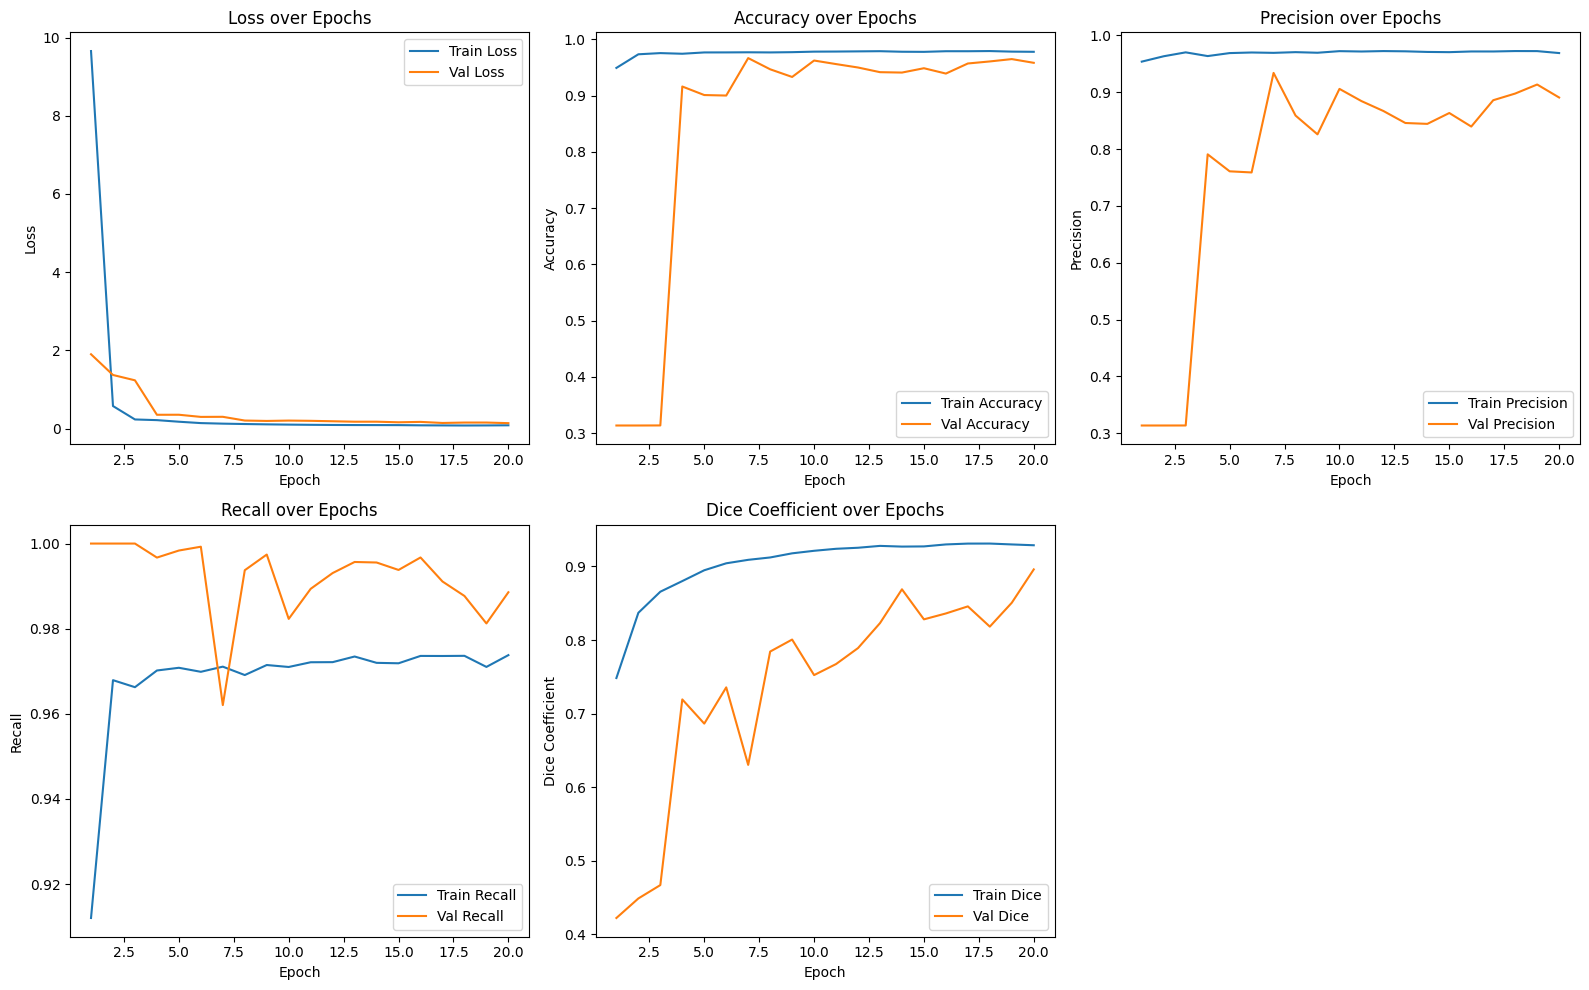


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Trained_with_1_site_2025-02-18-21-58\Model_Data
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9590 - dice_coef: 0.9131 - loss: 0.1844 - precision: 0.9793 - recall: 0.9133


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Trained_with_1_site
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/fcd8eb14104743599659c7c95bf1c245
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                 : (0.9493326544761658, 0.9793001413345337)
COMET INFO:     batch_accuracy [80]           : (0.5970226526260376, 0.9866471290588379)
COMET INFO:     batch_dice_coef [80]          : (0.27609750628471375, 0.9606069922447205)
COMET INFO:     batch_loss [80]               : (0.0703459158539772, 47.24631118774414)
COMET INFO:     batch_precision [80]          : (0.023811541497707367, 0.9875224828720093)
COMET INFO:     batch_re

In [5]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.25, 0.25) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 32
EPOCHS = 20
experiment_name = "Trained_with_1_site"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/9a0ea914fdb54f76b39d455bdafa8da3



---------Training Tiles---------

DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 1718
Number of pairs with 20.0% or less snow pixels: 858
Number of pairs with 80.0% or more snow pixels: 770
Selected 3346 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 1574
Number of pairs with 20.0% or less snow pixels: 787
Number of pairs with 80.0%

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 512, 512, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_33 (Conv2D)            │ (None, 512, 512, 16)      │             576 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_26        │ (None, 512, 512, 16)      │              64 │ conv2d_33[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_26 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_26[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_13 (Dropout)          │ (None, 512, 512, 16)      │               0 │ activation_26[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_34 (Conv2D)            │ (None, 512, 512, 16)      │           2,304 │ dropout_13[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_27        │ (None, 512, 512, 16)      │              64 │ conv2d_34[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_27 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_27[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 256, 256, 16)      │               0 │ activation_27[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_35 (Conv2D)            │ (None, 256, 256, 32)      │           4,608 │ max_pooling2d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_28        │ (None, 256, 256, 32)      │             128 │ conv2d_35[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_28 (Activation)    │ (None, 256, 256, 32)      │               0 │ batch_normalization_28[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_14 (Dropout)          │ (None, 256, 256, 32)      │               0 │ activation_28[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_36 (Conv2D)            │ (None, 256, 256, 32)      │           9,216 │ dropout_14[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_29        │ (None, 256, 256, 32)      │             128 │ conv2d_36[0][0]            │
│ (BatchNormalization)          │                           │               

 Total params: 34,622,785 (132.08 MB)

 Trainable params: 34,610,625 (132.03 MB)

 Non-trainable params: 12,160 (47.50 KB)

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 32
Number of epochs: 20
Steps per epoch (auto): 52
Epoch 1/20
Batch 0: loss = 47.1243
Batch 1: loss = 44.4816━━━━━━━━━━━━━━━━ 18:40 22s/step - accuracy: 0.6364 - dice_coef: 0.5324 - loss: 47.1243 - precision_1: 0.6530 - recall_1: 0.5495
Batch 2: loss = 41.9616━━━━━━━━━━━━━━━━ 9:16 11s/step - accuracy: 0.6916 - dice_coef: 0.5399 - loss: 45.8029 - precision_1: 0.6708 - recall_1: 0.6210 
Batch 3: loss = 39.5234m━━━━━━━━━━━━━━━━━━━ 9:01 11s/step - accuracy: 0.7201 - dice_coef: 0.5578 - loss: 44.5225 - precision_1: 0.7055 - recall_1: 0.6503
Batch 4: loss = 37.2097m━━━━━━━━━━━━━━━━━━━ 8:46 11s/step - accuracy: 0.7455 - dice_coef: 0.5752 - loss: 43.2727 - precision_1: 0.7330 - recall_1: 0.6774
Batch 5: loss = 35.0264m━━━━━━━━━━━━━━━━━━━ 8:33 11s/step - accuracy: 0.7659 - dice_coef: 0.5918 - loss: 42.0601 - precision_1: 0.7551 - recall_1: 0.7008
Batch 6: loss = 32.97250m━━━━━━━━━━━━━━━━━━ 8:24 11s/step - accuracy: 0.7824 - dice_coef: 0.6057 - loss: 40.8878 - precision

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet.py:208: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet.py:217: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


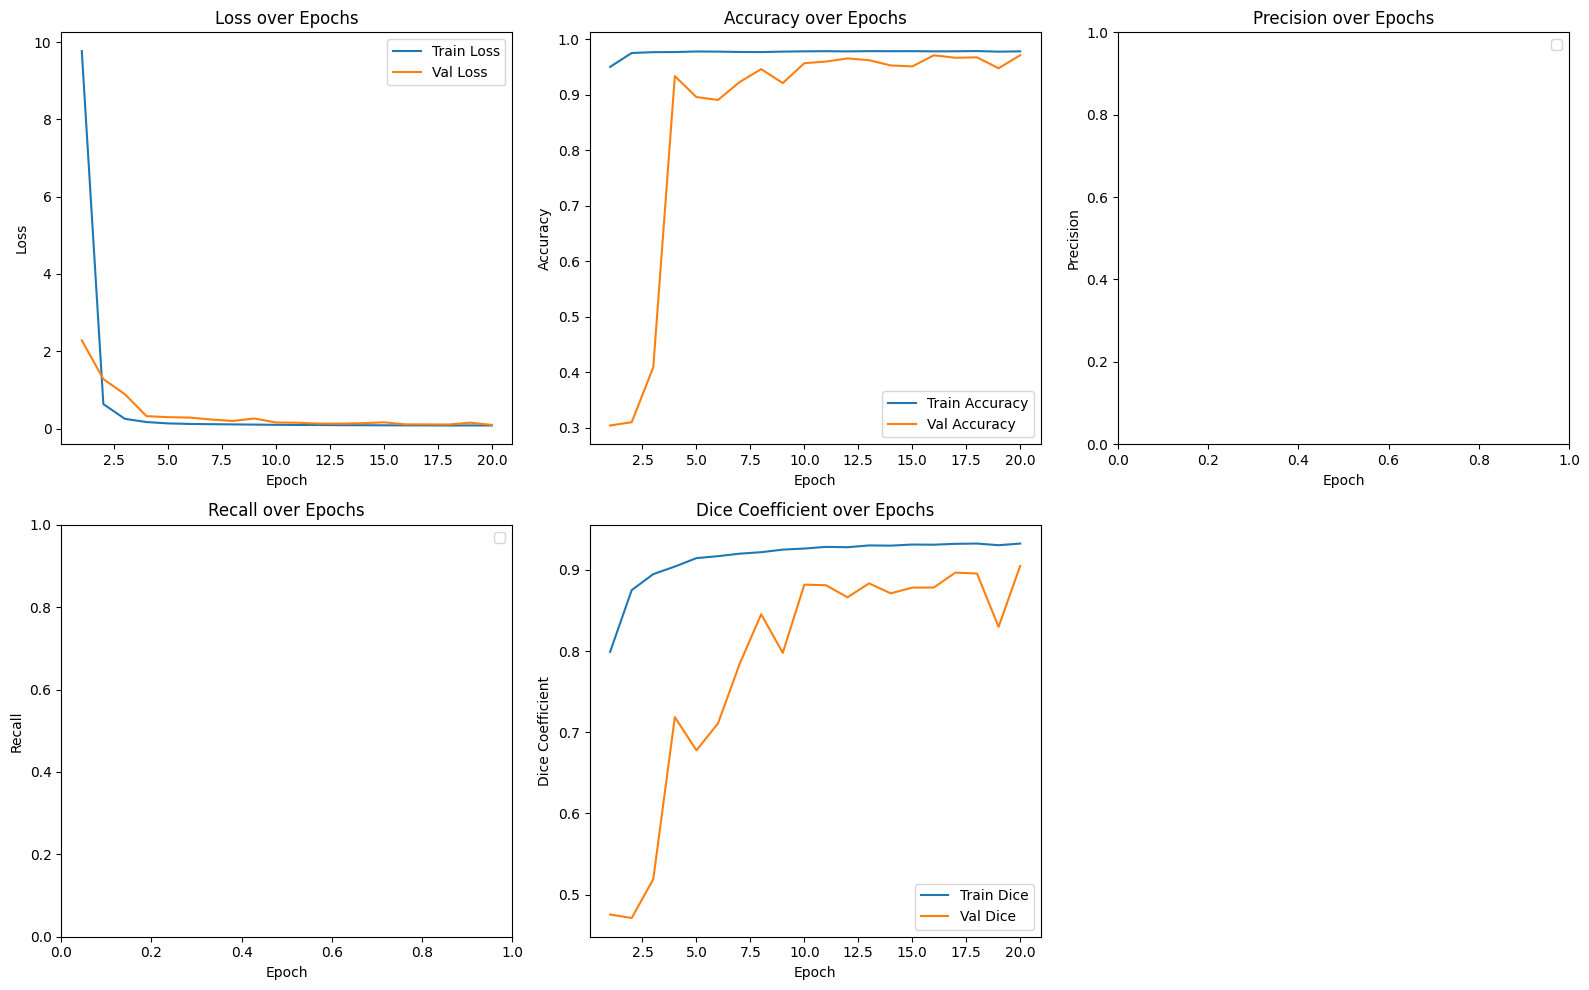


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Trained_with_2_sites_2025-02-19-00-39\Model_Data
15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9407 - dice_coef: 0.8859 - loss: 0.2648 - precision_1: 0.9950 - recall_1: 0.8552


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Trained_with_2_sites
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/9a0ea914fdb54f76b39d455bdafa8da3
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                   : (0.9501886367797852, 0.9786955118179321)
COMET INFO:     batch_accuracy [80]             : (0.6363917589187622, 0.9819337129592896)
COMET INFO:     batch_dice_coef [80]            : (0.5324406623840332, 0.9657992720603943)
COMET INFO:     batch_loss [80]           

In [6]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.25, 0.25) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 32
EPOCHS = 20
experiment_name = "Trained_with_2_sites"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/885013abe71a4242ad5756f39f7f10f5



---------Training Tiles---------

DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

Elkton: 
Num of pairs: 11662
Num of pairs with 20.0% to 80.0% snow pixels: 1351
Num of pairs with 20.0% or less snow pixels: 8641
Num of pairs with 80.0% or more snow pixels: 1670
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 3069
Number of pairs with 20.0% or less snow pixels: 1533
Number of pairs with 80.0% or more snow pixels: 1445
Selected 6047 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 512, 512, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_66 (Conv2D)            │ (None, 512, 512, 16)      │             576 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_52        │ (None, 512, 512, 16)      │              64 │ conv2d_66[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_52 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_52[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_26 (Dropout)          │ (None, 512, 512, 16)      │               0 │ activation_52[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_67 (Conv2D)            │ (None, 512, 512, 16)      │           2,304 │ dropout_26[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_53        │ (None, 512, 512, 16)      │              64 │ conv2d_67[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_53 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_53[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_12              │ (None, 256, 256, 16)      │               0 │ activation_53[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_68 (Conv2D)            │ (None, 256, 256, 32)      │           4,608 │ max_pooling2d_12[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_54        │ (None, 256, 256, 32)      │             128 │ conv2d_68[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_54 (Activation)    │ (None, 256, 256, 32)      │               0 │ batch_normalization_54[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_27 (Dropout)          │ (None, 256, 256, 32)      │               0 │ activation_54[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_69 (Conv2D)            │ (None, 256, 256, 32)      │           9,216 │ dropout_27[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_55        │ (None, 256, 256, 32)      │             128 │ conv2d_69[0][0]            │
│ (BatchNormalization)          │                           │               

 Total params: 34,622,785 (132.08 MB)

 Trainable params: 34,610,625 (132.03 MB)

 Non-trainable params: 12,160 (47.50 KB)

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 32
Number of epochs: 20
Steps per epoch (auto): 94
Epoch 1/20
Batch 0: loss = 47.3367
Batch 1: loss = 44.6736━━━━━━━━━━━━━━━━ 32:35 21s/step - accuracy: 0.3680 - dice_coef: 0.4488 - loss: 47.3367 - precision_2: 0.2996 - recall_2: 0.9879
Batch 2: loss = 42.1414━━━━━━━━━━━━━━━━ 16:29 11s/step - accuracy: 0.4031 - dice_coef: 0.4766 - loss: 46.0052 - precision_2: 0.3228 - recall_2: 0.9888
Batch 3: loss = 39.7502━━━━━━━━━━━━━━━━ 16:16 11s/step - accuracy: 0.4471 - dice_coef: 0.4970 - loss: 44.7173 - precision_2: 0.3476 - recall_2: 0.9883
Batch 4: loss = 37.4515━━━━━━━━━━━━━━━━ 16:10 11s/step - accuracy: 0.4795 - dice_coef: 0.5059 - loss: 43.4755 - precision_2: 0.3618 - recall_2: 0.9874
Batch 5: loss = 35.2824m━━━━━━━━━━━━━━━━━━━ 16:04 11s/step - accuracy: 0.5114 - dice_coef: 0.5174 - loss: 42.2707 - precision_2: 0.3830 - recall_2: 0.9827
Batch 6: loss = 33.2396m━━━━━━━━━━━━━━━━━━━ 15:52 11s/step - accuracy: 0.5409 - dice_coef: 0.5278 - loss: 41.1060 - precision_2: 

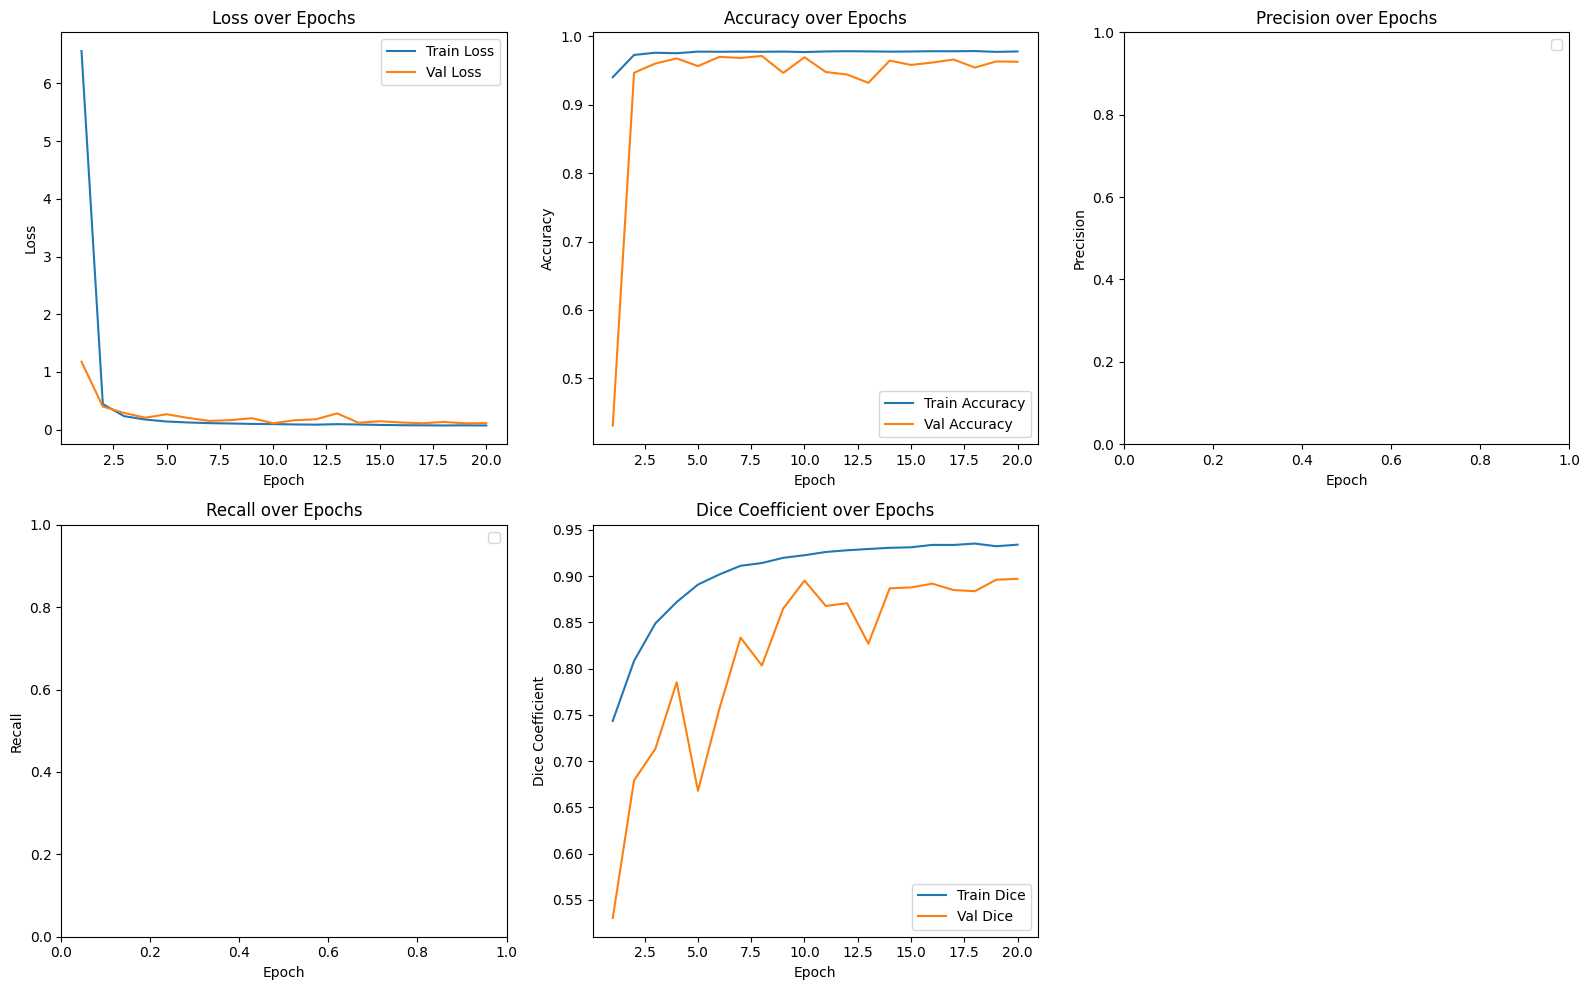


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Trained_with_3_sites_2025-02-19-03-22\Model_Data
15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9684 - dice_coef: 0.9312 - loss: 0.1318 - precision_2: 0.9796 - recall_2: 0.9408


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Trained_with_3_sites
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/885013abe71a4242ad5756f39f7f10f5
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                   : (0.9404283761978149, 0.9786896705627441)
COMET INFO:     batch_accuracy [140]            : (0.3680400848388672, 0.9846688508987427)
COMET INFO:     batch_dice_coef [140]           : (0.4488254189491272, 0.9551516771316528)
COMET INFO:     batch_loss [140]          

In [7]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.25, 0.25) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 32
EPOCHS = 20
experiment_name = "Trained_with_3_sites"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/aa83dcd23cd24ca7a37067196aaa8eec



---------Training Tiles---------

DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 1383
Number of pairs with 20.0% or less snow pixels: 968
Number of pairs with 80.0% or more snow pixels: 414
Selected 2765 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 1574
Number of pairs with 20.0% or less snow pixels: 1101
Number of pairs with 80.0% or more snow pixels: 472
Selected 3147 valid (img, msk) pairs

---------Testing Tiles---------

VirginiaBasin: 
Num of pairs: 6023
Num of pairs with 20.0% to 80.0% snow pixels: 260
Nu

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 512, 512, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 512, 512, 16)      │             576 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 512, 512, 16)      │              64 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 512, 512, 16)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 512, 512, 16)      │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 512, 512, 16)      │           2,304 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 512, 512, 16)      │              64 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 512, 512, 16)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 256, 256, 16)      │               0 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 256, 256, 32)      │           4,608 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 256, 256, 32)      │             128 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 256, 256, 32)      │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 256, 256, 32)      │               0 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 256, 256, 32)      │           9,216 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 256, 256, 32)      │             128 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 34,622,785 (132.08 MB)

...

 Non-trainable params: 12,160 (47.50 KB)

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Training with batch size: 32
Number of epochs: 20
Steps per epoch (auto): 43
Epoch 1/20
Batch 0: loss = 47.0941
Batch 1: loss = 44.3990━━━━━━━━━━━━━━━━ 15:38 22s/step - accuracy: 0.6259 - dice_coef: 0.4826 - loss: 47.0941 - precision: 0.4616 - recall: 0.8825
Batch 2: loss = 41.8177━━━━━━━━━━━━━━━━ 7:26 11s/step - accuracy: 0.6858 - dice_coef: 0.5251 - loss: 45.7466 - precision: 0.5222 - recall: 0.9081 
Batch 3: loss = 39.3556m━━━━━━━━━━━━━━━━━━━ 7:13 11s/step - accuracy: 0.7238 - dice_coef: 0.5468 - loss: 44.4369 - precision: 0.5581 - recall: 0.9206
Batch 4: loss = 37.0049m━━━━━━━━━━━━━━━━━━━ 7:03 11s/step - accuracy: 0.7504 - dice_coef: 0.5593 - loss: 43.1666 - precision: 0.5821 - recall: 0.9284
Batch 5: loss = 34.80420m━━━━━━━━━━━━━━━━━━ 6:54 11s/step - accuracy: 0.7706 - dice_coef: 0.5714 - loss: 41.9343 - precision: 0.6036 - recall: 0.9337
Batch 6: loss = 32.73110m━━━━━━━━━━━━━━━━━━ 6:44 11s/step - accuracy: 0.7870 - dice_coef: 0.5795 - loss: 40.7459 - precision: 0.6209 - recall: 0

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\tensor_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from inf to 2.47997, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000978
43/43 ━━━━━━━━━━━━━━━━━━━━ 528s 12s/step - accuracy: 0.9166 - dice_coef: 0.6932 - loss: 19.4247 - precision: 0.8172 - recall: 0.9651 - val_accuracy: 0.2606 - val_dice_coef: 0.4029 - val_loss: 2.4800 - val_precision: 0.2606 - val_recall: 1.0000
Epoch 2/20
Batch 0: loss = 1.0283
Batch 1: loss = 0.9970━━━━━━━━━━━━━━━━━ 8:25 12s/step - accuracy: 0.9810 - dice_coef: 0.8307 - loss: 1.0283 - precision: 0.9713 - recall: 0.9711
Batch 2: loss = 0.9777━━━━━━━━━━━━━━━━━ 7:27 11s/step - accuracy: 0.9801 - dice_coef: 0.8334 - loss: 1.0126 - precision: 0.9661 - recall: 0.9744
Batch 3: loss = 0.95860m━━━━━━━━━━━━━━━━━━━ 7:13 11s/step - accuracy: 0.9790 - dice_coef: 0.8318 - loss: 1.0010 - precision: 0.9604 - recall: 0.9768
Batch 4: loss = 0.93520m━━━━━━━━━━━━━━━━━━━ 7:01 11s/step -

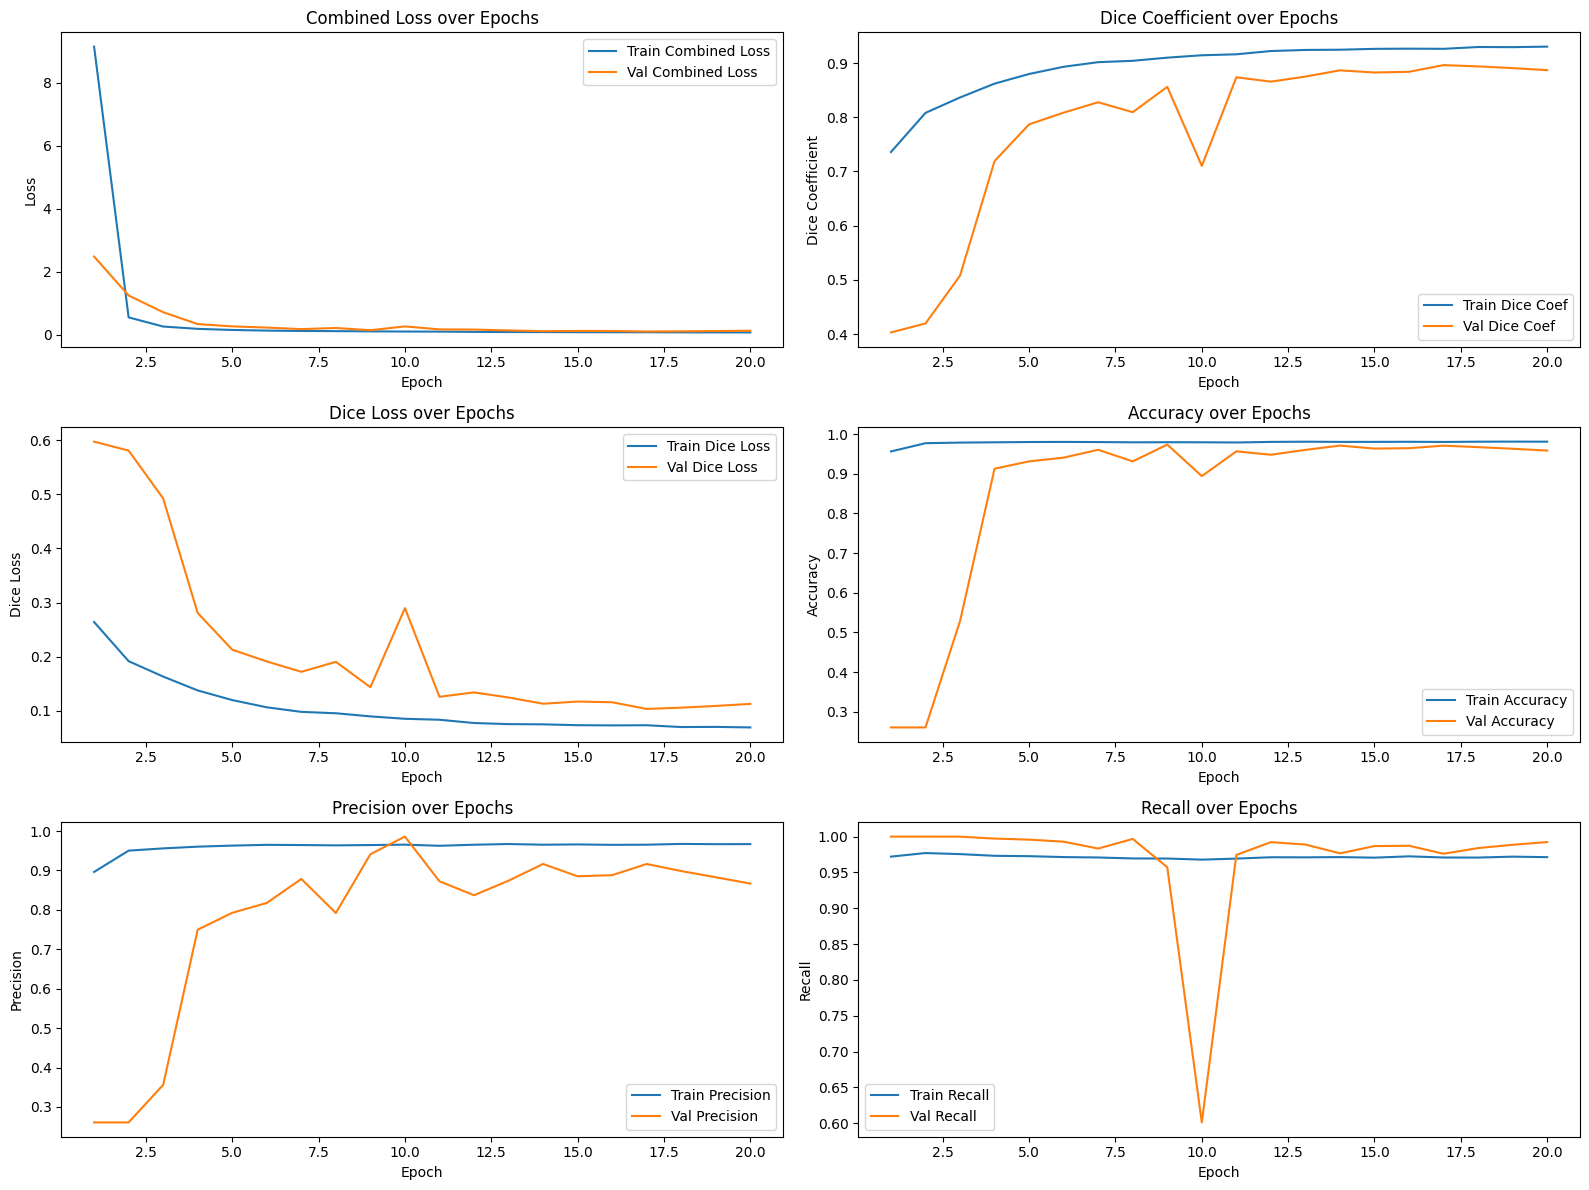


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\combined_loss_trained_on_1_site_2025-02-23-18-34\Model_Data
17/17 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9563 - dice_coef: 0.8990 - loss: 0.1419 - precision: 0.9810 - recall: 0.9009


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : combined_loss_trained_on_1_site
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/aa83dcd23cd24ca7a37067196aaa8eec
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                 : (0.9560398459434509, 0.9807925224304199)
COMET INFO:     batch_accuracy [80]           : (0.6259361505508423, 0.9850684404373169)
COMET INFO:     batch_dice_coef [80]          : (0.4825612008571625, 0.9614525437355042)
COMET INFO:     batch_loss [80]               : (0.07047057896852493, 47.09408950805664)
COMET INFO:     batch_precision [80]          : (0.46163398027420044, 0.9873538613319397)
COMET INFO:  

In [5]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.35, 0.15) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 32
EPOCHS = 20
experiment_name = "combined_loss_trained_on_1_site"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/f150478fcfda42759d50af5b66bd6eaf



---------Training Tiles---------

DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 1718
Number of pairs with 20.0% or less snow pixels: 1202
Number of pairs with 80.0% or more snow pixels: 493
Selected 3413 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 1574
Number of pairs with 20.0% or less snow pixels: 1101
Number of pairs with 80.

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 512, 512, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_33 (Conv2D)            │ (None, 512, 512, 16)      │             576 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_26        │ (None, 512, 512, 16)      │              64 │ conv2d_33[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_26 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_26[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_13 (Dropout)          │ (None, 512, 512, 16)      │               0 │ activation_26[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_34 (Conv2D)            │ (None, 512, 512, 16)      │           2,304 │ dropout_13[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_27        │ (None, 512, 512, 16)      │              64 │ conv2d_34[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_27 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_27[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 256, 256, 16)      │               0 │ activation_27[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_35 (Conv2D)            │ (None, 256, 256, 32)      │           4,608 │ max_pooling2d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_28        │ (None, 256, 256, 32)      │             128 │ conv2d_35[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_28 (Activation)    │ (None, 256, 256, 32)      │               0 │ batch_normalization_28[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_14 (Dropout)          │ (None, 256, 256, 32)      │               0 │ activation_28[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_36 (Conv2D)            │ (None, 256, 256, 32)      │           9,216 │ dropout_14[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_29        │ (None, 256, 256, 32)      │             128 │ conv2d_36[0][0]            │
│ (BatchNormalization)          │                           │               

 Total params: 34,622,785 (132.08 MB)

 Trainable params: 34,610,625 (132.03 MB)

 Non-trainable params: 12,160 (47.50 KB)

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 32
Number of epochs: 20
Steps per epoch (auto): 53
Epoch 1/20
Batch 0: loss = 47.2077
Batch 1: loss = 44.8138━━━━━━━━━━━━━━━━ 17:53 21s/step - accuracy: 0.4352 - dice_coef: 0.4047 - loss: 47.2077 - precision_1: 0.3319 - recall_1: 0.7456
Batch 2: loss = 42.3979━━━━━━━━━━━━━━━━ 9:08 11s/step - accuracy: 0.4611 - dice_coef: 0.4255 - loss: 46.0108 - precision_1: 0.3441 - recall_1: 0.7943 
Batch 3: loss = 40.0420m━━━━━━━━━━━━━━━━━━━ 8:57 11s/step - accuracy: 0.4913 - dice_coef: 0.4444 - loss: 44.8065 - precision_1: 0.3598 - recall_1: 0.8238
Batch 4: loss = 37.7787m━━━━━━━━━━━━━━━━━━━ 8:46 11s/step - accuracy: 0.5239 - dice_coef: 0.4623 - loss: 43.6154 - precision_1: 0.3804 - recall_1: 0.8427
Batch 5: loss = 35.6319m━━━━━━━━━━━━━━━━━━━ 8:38 11s/step - accuracy: 0.5545 - dice_coef: 0.4793 - loss: 42.4480 - precision_1: 0.4023 - recall_1: 0.8564
Batch 6: loss = 33.60560m━━━━━━━━━━━━━━━━━━ 8:28 11s/step - accuracy: 0.5813 - dice_coef: 0.4944 - loss: 41.3120 - precision

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:242: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,0].legend()
C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:252: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,1].legend()


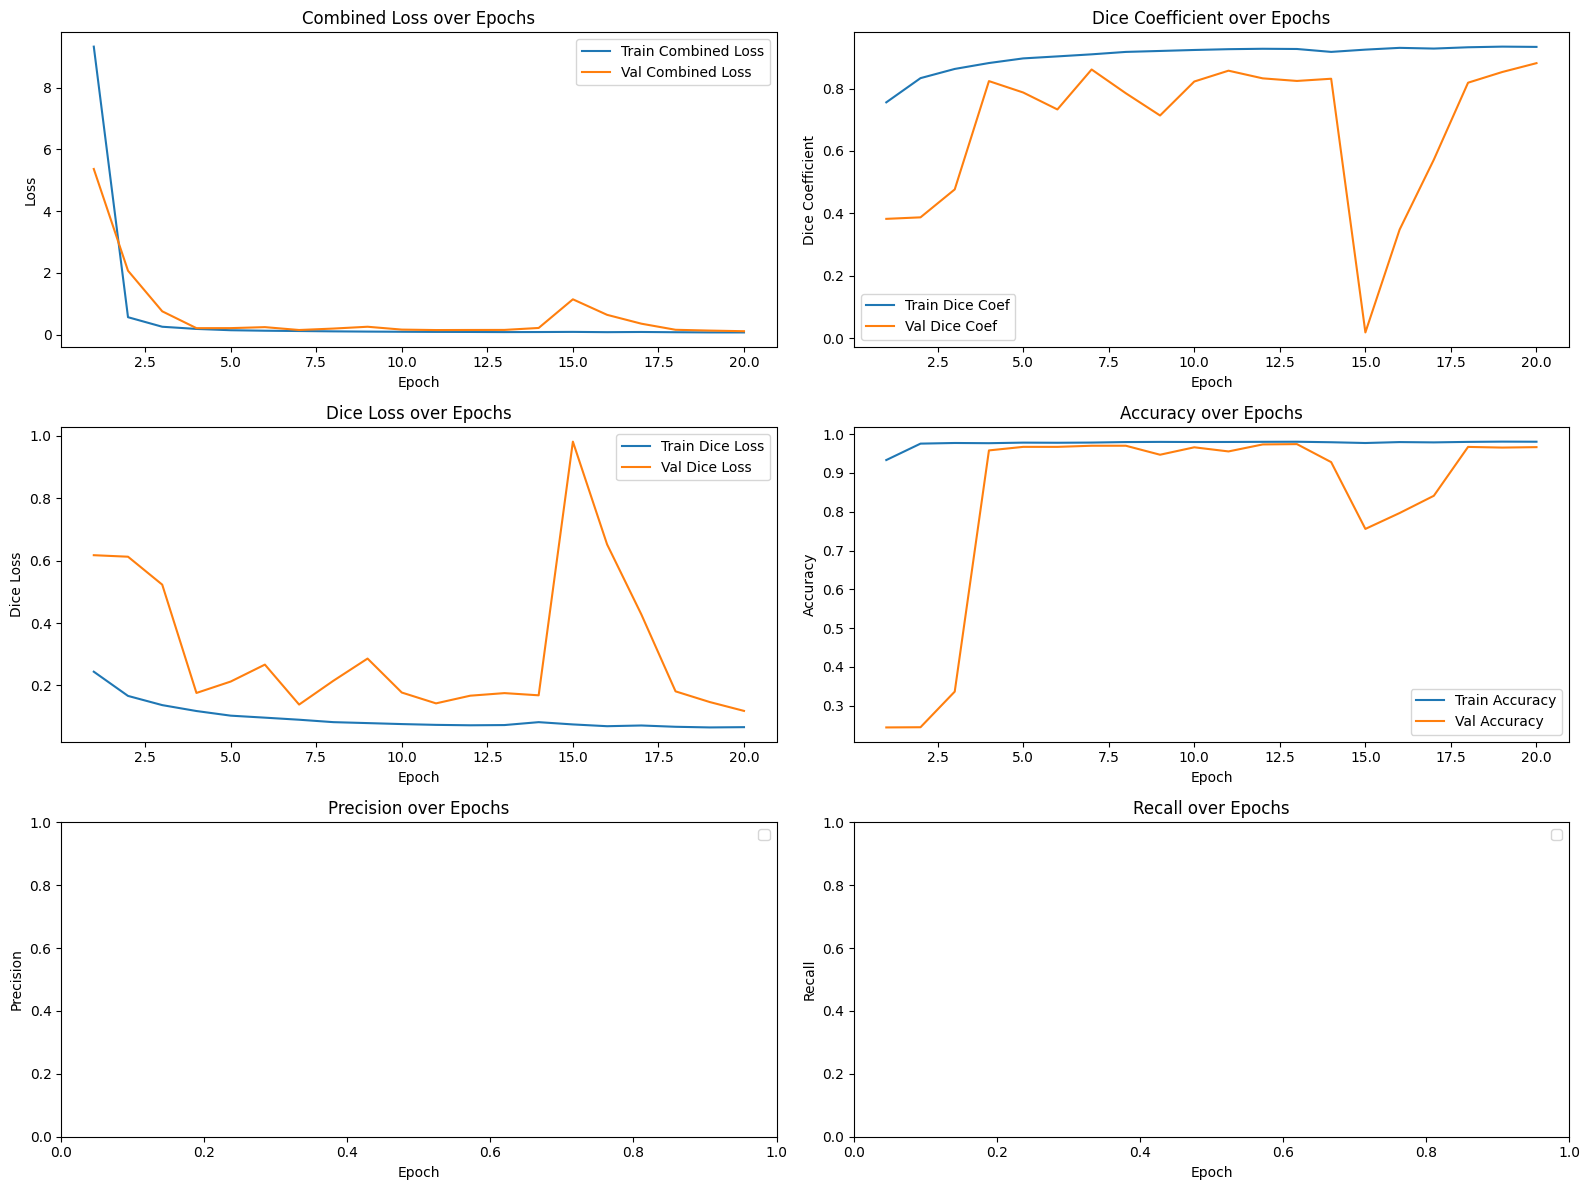


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\combined_loss_trained_on_2_site_2025-02-23-21-26\Model_Data
17/17 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9675 - dice_coef: 0.9028 - loss: 0.1277 - precision_1: 0.9754 - recall_1: 0.9374


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : combined_loss_trained_on_2_site
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/f150478fcfda42759d50af5b66bd6eaf
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                   : (0.9331995844841003, 0.9806655049324036)
COMET INFO:     batch_accuracy [100]            : (0.435207724571228, 0.9822244644165039)
COMET INFO:     batch_dice_coef [100]           : (0.40471816062927246, 0.9574953317642212)
COMET INFO:     batch_loss [100

In [6]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail","EastRiverTrail"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.35, 0.15) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 32
EPOCHS = 20
experiment_name = "combined_loss_trained_on_2_site"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/dd5d6446a69e45a7a1f93abb8c1d1920



---------Training Tiles---------

DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

JuddFalls: 
Num of pairs: 5256
Num of pairs with 20.0% to 80.0% snow pixels: 1196
Num of pairs with 20.0% or less snow pixels: 2694
Num of pairs with 80.0% or more snow pixels: 1366
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 2914
Number of pairs with 20.0% or less snow pixels: 2039
Number of pairs with 80.0% or more snow pixels: 851
Selected 5804 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 512, 512, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_66 (Conv2D)            │ (None, 512, 512, 16)      │             576 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_52        │ (None, 512, 512, 16)      │              64 │ conv2d_66[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_52 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_52[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_26 (Dropout)          │ (None, 512, 512, 16)      │               0 │ activation_52[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_67 (Conv2D)            │ (None, 512, 512, 16)      │           2,304 │ dropout_26[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_53        │ (None, 512, 512, 16)      │              64 │ conv2d_67[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_53 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_53[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_12              │ (None, 256, 256, 16)      │               0 │ activation_53[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_68 (Conv2D)            │ (None, 256, 256, 32)      │           4,608 │ max_pooling2d_12[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_54        │ (None, 256, 256, 32)      │             128 │ conv2d_68[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_54 (Activation)    │ (None, 256, 256, 32)      │               0 │ batch_normalization_54[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_27 (Dropout)          │ (None, 256, 256, 32)      │               0 │ activation_54[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_69 (Conv2D)            │ (None, 256, 256, 32)      │           9,216 │ dropout_27[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_55        │ (None, 256, 256, 32)      │             128 │ conv2d_69[0][0]            │
│ (BatchNormalization)          │                           │               

 Total params: 34,622,785 (132.08 MB)

 Trainable params: 34,610,625 (132.03 MB)

 Non-trainable params: 12,160 (47.50 KB)

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 32
Number of epochs: 20
Steps per epoch (auto): 90
Epoch 1/20
Batch 0: loss = 47.1494
Batch 1: loss = 44.8051━━━━━━━━━━━━━━━━ 31:12 21s/step - accuracy: 0.5121 - dice_coef: 0.4539 - loss: 47.1494 - precision_2: 0.4128 - recall_2: 0.7489
Batch 2: loss = 42.4567━━━━━━━━━━━━━━━━ 15:39 11s/step - accuracy: 0.5359 - dice_coef: 0.4636 - loss: 45.9773 - precision_2: 0.4159 - recall_2: 0.7942
Batch 3: loss = 40.1229━━━━━━━━━━━━━━━━ 15:28 11s/step - accuracy: 0.5565 - dice_coef: 0.4672 - loss: 44.8038 - precision_2: 0.4145 - recall_2: 0.8196
Batch 4: loss = 37.8914━━━━━━━━━━━━━━━━ 15:17 11s/step - accuracy: 0.5852 - dice_coef: 0.4802 - loss: 43.6335 - precision_2: 0.4313 - recall_2: 0.8396
Batch 5: loss = 35.7617m━━━━━━━━━━━━━━━━━━━ 15:07 11s/step - accuracy: 0.6121 - dice_coef: 0.4939 - loss: 42.4851 - precision_2: 0.4507 - recall_2: 0.8541
Batch 6: loss = 33.7552m━━━━━━━━━━━━━━━━━━━ 15:00 11s/step - accuracy: 0.6360 - dice_coef: 0.5079 - loss: 41.3646 - precision_2: 

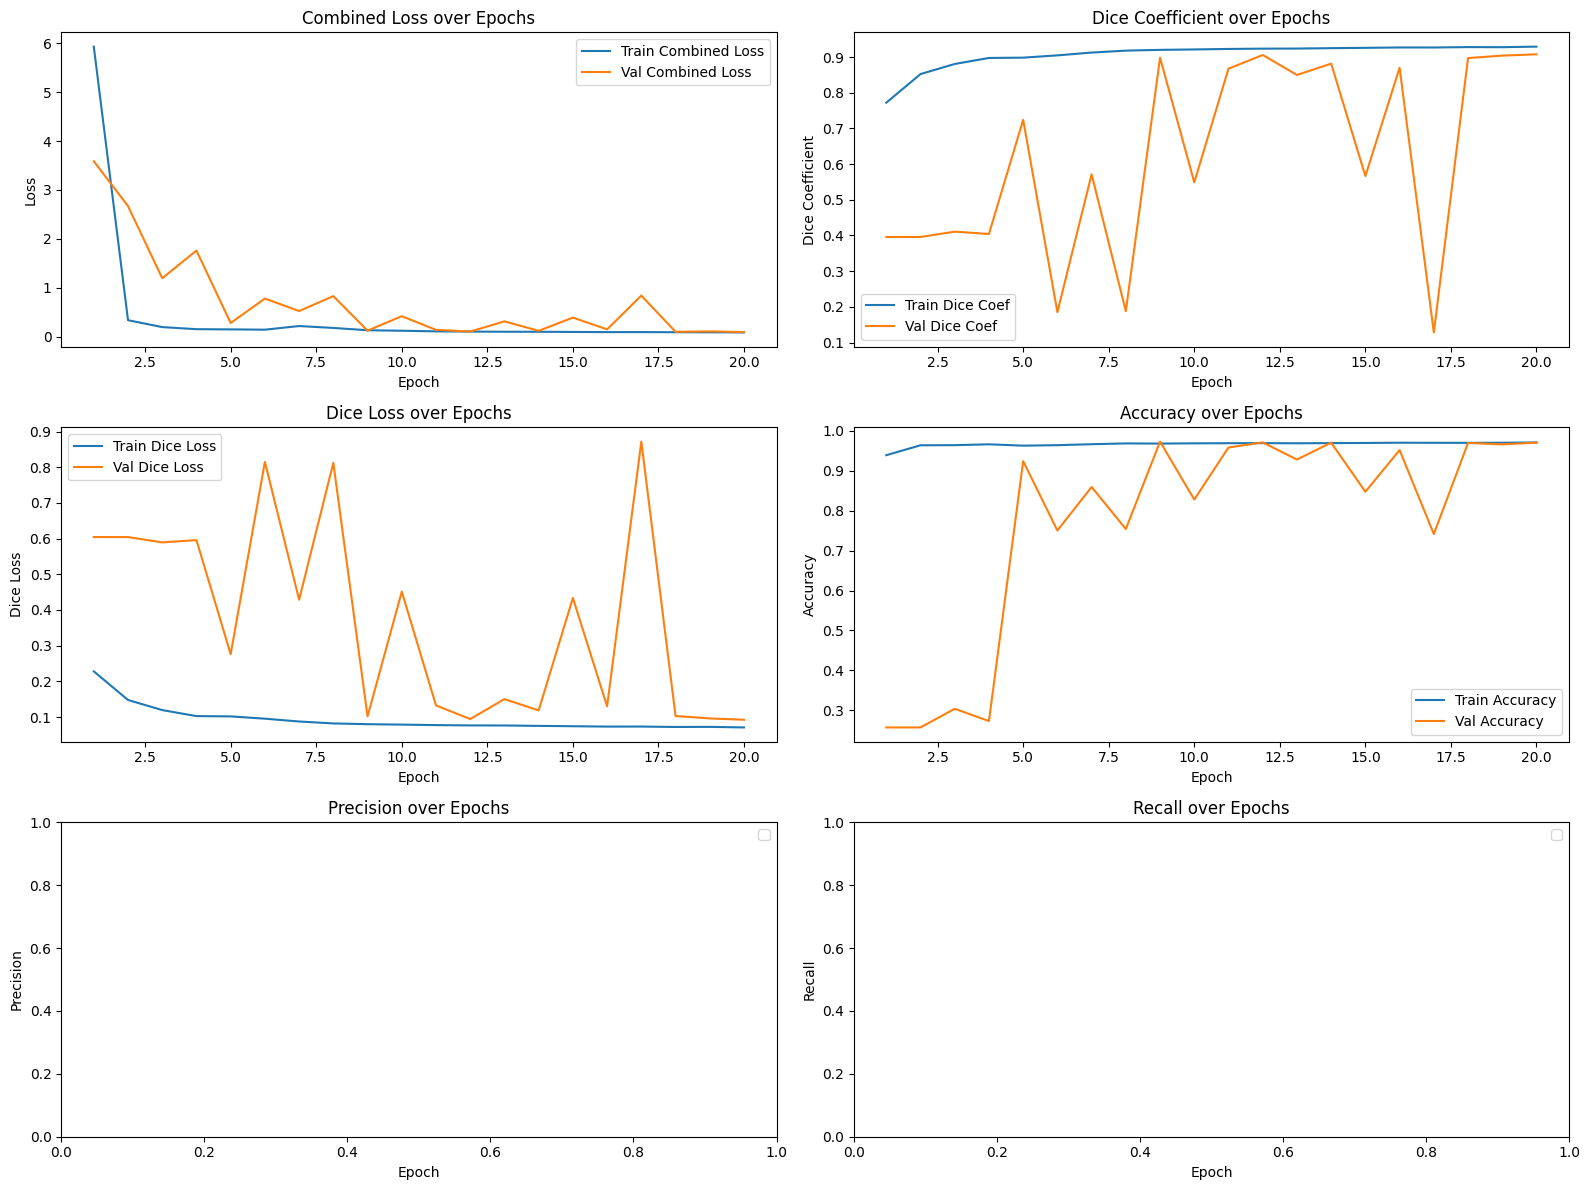


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\combined_loss_trained_on_3_site_2025-02-24-00-24\Model_Data
17/17 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9654 - dice_coef: 0.9235 - loss: 0.1216 - precision_2: 0.9756 - recall_2: 0.9289


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : combined_loss_trained_on_3_site
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/dd5d6446a69e45a7a1f93abb8c1d1920
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                   : (0.9393121004104614, 0.9712346792221069)
COMET INFO:     batch_accuracy [140]            : (0.5121430158615112, 0.9816445112228394)
COMET INFO:     batch_dice_coef [140]           : (0.45391160249710083, 0.9563084244728088)
COMET INFO:     batch_loss [14

In [7]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "JuddFalls"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.35, 0.15) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 32
EPOCHS = 20
experiment_name = "combined_loss_trained_on_3_site"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "JuddFalls", "LupineTrail"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.35, 0.15) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 32
EPOCHS = 20
experiment_name = "combined_loss_trained_on_4_site"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/787231fa55264067a84862f57496f07e



---------Training Tiles---------

DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

JuddFalls: 
Num of pairs: 5256
Num of pairs with 20.0% to 80.0% snow pixels: 1196
Num of pairs with 20.0% or less snow pixels: 2694
Num of pairs with 80.0% or more snow pixels: 1366

LupineTrail: 
Num of pairs: 11560
Num of pairs with 20.0% to 80.0% snow pixels: 1370
Num of pairs with 20.0% or less snow pixels: 7366
Num of pairs with 80.0% or more snow pixels: 2824
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 4284
Number of pairs with 20.0% or less snow pixels: 2997
Number of pairs with 80.0% or more snow pixels: 1262
Selected 8543 valid (img, msk) pairs

---

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 512, 512, 4)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_99 (Conv2D)            │ (None, 512, 512, 16)      │             576 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_78        │ (None, 512, 512, 16)      │              64 │ conv2d_99[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_78 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_78[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_39 (Dropout)          │ (None, 512, 512, 16)      │               0 │ activation_78[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_100 (Conv2D)           │ (None, 512, 512, 16)      │           2,304 │ dropout_39[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_79        │ (None, 512, 512, 16)      │              64 │ conv2d_100[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_79 (Activation)    │ (None, 512, 512, 16)      │               0 │ batch_normalization_79[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_18              │ (None, 256, 256, 16)      │               0 │ activation_79[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_101 (Conv2D)           │ (None, 256, 256, 32)      │           4,608 │ max_pooling2d_18[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_80        │ (None, 256, 256, 32)      │             128 │ conv2d_101[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_80 (Activation)    │ (None, 256, 256, 32)      │               0 │ batch_normalization_80[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_40 (Dropout)          │ (None, 256, 256, 32)      │               0 │ activation_80[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_102 (Conv2D)           │ (None, 256, 256, 32)      │           9,216 │ dropout_40[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_81        │ (None, 256, 256, 32)      │             128 │ conv2d_102[0][0]           │
│ (BatchNormalization)          │                           │               

 Total params: 34,622,785 (132.08 MB)

 Trainable params: 34,610,625 (132.03 MB)

 Non-trainable params: 12,160 (47.50 KB)

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 32
Number of epochs: 20
Steps per epoch (auto): 133
Epoch 1/20
Batch 0: loss = 47.0906
Batch 1: loss = 44.5197━━━━━━━━━━━━━━━━━━ 45:48 21s/step - accuracy: 0.5315 - dice_coef: 0.5300 - loss: 47.0906 - precision_3: 0.4475 - recall_3: 0.9009
Batch 2: loss = 42.0123━━━━━━━━━━━━━━━━━━ 23:31 11s/step - accuracy: 0.5714 - dice_coef: 0.5436 - loss: 45.8052 - precision_3: 0.4634 - recall_3: 0.9170
Batch 3: loss = 39.5575━━━━━━━━━━━━━━━━━━ 23:24 11s/step - accuracy: 0.5976 - dice_coef: 0.5471 - loss: 44.5409 - precision_3: 0.4702 - recall_3: 0.9249
Batch 4: loss = 37.2274━━━━━━━━━━━━━━━━━━ 23:12 11s/step - accuracy: 0.6268 - dice_coef: 0.5584 - loss: 43.2950 - precision_3: 0.4893 - recall_3: 0.9312
Batch 5: loss = 35.0464━━━━━━━━━━━━━━━━━━ 22:58 11s/step - accuracy: 0.6537 - dice_coef: 0.5721 - loss: 42.0815 - precision_3: 0.5123 - recall_3: 0.9360
Batch 6: loss = 32.9889━━━━━━━━━━━━━━━━━━ 22:50 11s/step - accuracy: 0.6762 - dice_coef: 0.5827 - loss: 40.9090 - precisio

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/92e4d09d74ec43a88aa626bb6bdfb149



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

Elkton: 
Num of pairs: 11662
Num of pairs with 20.0% to 80.0% snow pixels: 1351
Num of pairs with 20.0% or less snow pixels: 8641
Num of pairs with 80.0% or more snow pixels: 1670
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 3069
Number of pairs with 20.0% or less snow pixels: 1533
Number of pairs with 80.0% or more snow pixels: 1445
Selected 6047 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Tota

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Epoch 1/20
Batch 0: loss = 47.1067
Batch 1: loss = 44.42754s/step - loss: 47.1067 - accuracy: 0.5142 - precision: 0.4596 - recall: 0.7357 - dice_coef: 0.4833
Batch 2: loss = 41.785028ms/step - loss: 44.4275 - accuracy: 0.5716 - precision: 0.4611 - recall: 0.8213 - dice_coef: 0.5010
Batch 3: loss = 39.329077ms/step - loss: 41.7850 - accuracy: 0.6893 - precision: 0.5895 - recall: 0.8798 - dice_coef: 0.5790
Batch 4: loss = 36.972139ms/step - loss: 39.3290 - accuracy: 0.7165 - precision: 0.5861 - recall: 0.8953 - dice_coef: 0.5777
Batch 5: loss = 34.754755ms/step - loss: 36.9721 - accuracy: 0.7574 - precision: 0.6361 - recall: 0.8983 - dice_coef: 0.6089
Batch 6: loss = 32.686586ms/step - loss: 34.7547 - accuracy: 0.7891 - precision: 0.6740 - recall: 0.9118 - dice_coef: 0.6350
Batch 7: loss = 30.753665ms/step - loss: 32.6865 - accuracy: 0.8097 - precision: 0.6906 - recall: 0.9212 - dice_coef: 0.6474
Batch 8: loss = 28.967395ms/step - loss: 30.7536 - accuracy: 0.8260 - precision: 0.7095 - re

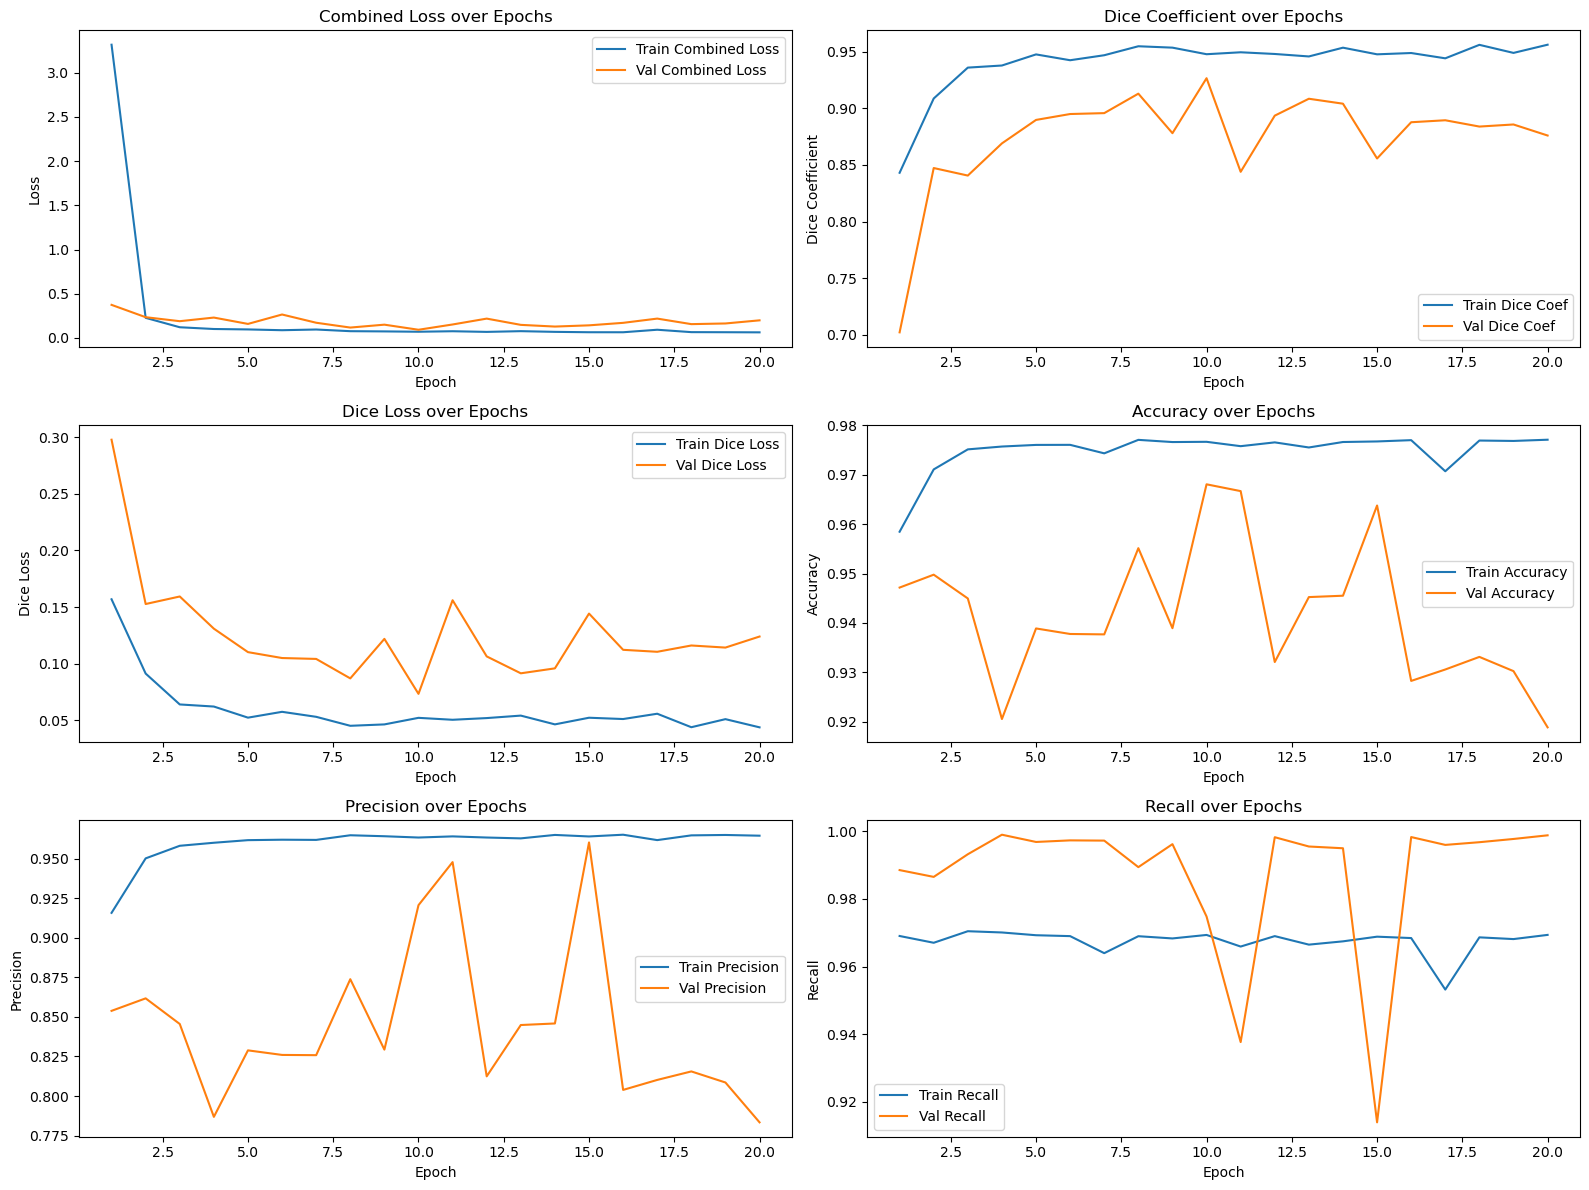


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_01_2025-03-06-14-21\Model_Data
30/30 [==============================] - 7s 223ms/step - loss: 0.1273 - accuracy: 0.9598 - precision: 0.9809 - recall: 0.9179 - dice_coef: 0.9320


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_01
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/92e4d09d74ec43a88aa626bb6bdfb149
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                  : (0.9584763050079346, 0.9771121144294739)
COMET INFO:     batch_accuracy [260]           : (0.5142431259155273, 0.982490062713623)
COMET INFO:     batch_dice_coef [260]          : (0.4833110272884369, 0.9650182127952576)
COMET INFO:     batch_loss [260]               : (0.051466964185237885, 47.10671615600586)
COMET INFO:     batch_precision [260]          : (0.4596068263053894, 0.9896792769432068)
COMET INFO:     batch_recall [26

In [6]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.25, 0.25) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_01"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/d045395995874f37abce579875d4d6fa



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

Elkton: 
Num of pairs: 11662
Num of pairs with 20.0% to 80.0% snow pixels: 1351
Num of pairs with 20.0% or less snow pixels: 8641
Num of pairs with 80.0% or more snow pixels: 1670
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 3069
Number of pairs with 20.0% or less snow pixels: 1840
Number of pairs with 80.0% or more snow pixels: 1172
Selected 6081 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Tota

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Epoch 1/20
Batch 0: loss = 47.2199
Batch 1: loss = 44.8540/step - loss: 47.2199 - accuracy: 0.5535 - precision_1: 0.1255 - recall_1: 0.1116 - dice_coef: 0.2672
Batch 2: loss = 42.59684ms/step - loss: 44.8540 - accuracy: 0.6957 - precision_1: 0.4284 - recall_1: 0.4024 - dice_coef: 0.3505
Batch 3: loss = 40.40843ms/step - loss: 42.5968 - accuracy: 0.7672 - precision_1: 0.6443 - recall_1: 0.5915 - dice_coef: 0.4299
Batch 4: loss = 38.27624ms/step - loss: 40.4084 - accuracy: 0.8184 - precision_1: 0.6985 - recall_1: 0.6619 - dice_coef: 0.4554
Batch 5: loss = 36.23100ms/step - loss: 38.2762 - accuracy: 0.8440 - precision_1: 0.7630 - recall_1: 0.7261 - dice_coef: 0.4982
Batch 6: loss = 34.27927ms/step - loss: 36.2310 - accuracy: 0.8635 - precision_1: 0.7925 - recall_1: 0.7666 - dice_coef: 0.5251
Batch 7: loss = 32.42666ms/step - loss: 34.2792 - accuracy: 0.8763 - precision_1: 0.8127 - recall_1: 0.7977 - dice_coef: 0.5489
Batch 8: loss = 30.71418ms/step - loss: 32.4266 - accuracy: 0.8870 - pre

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:242: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,0].legend()
C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:252: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,1].legend()


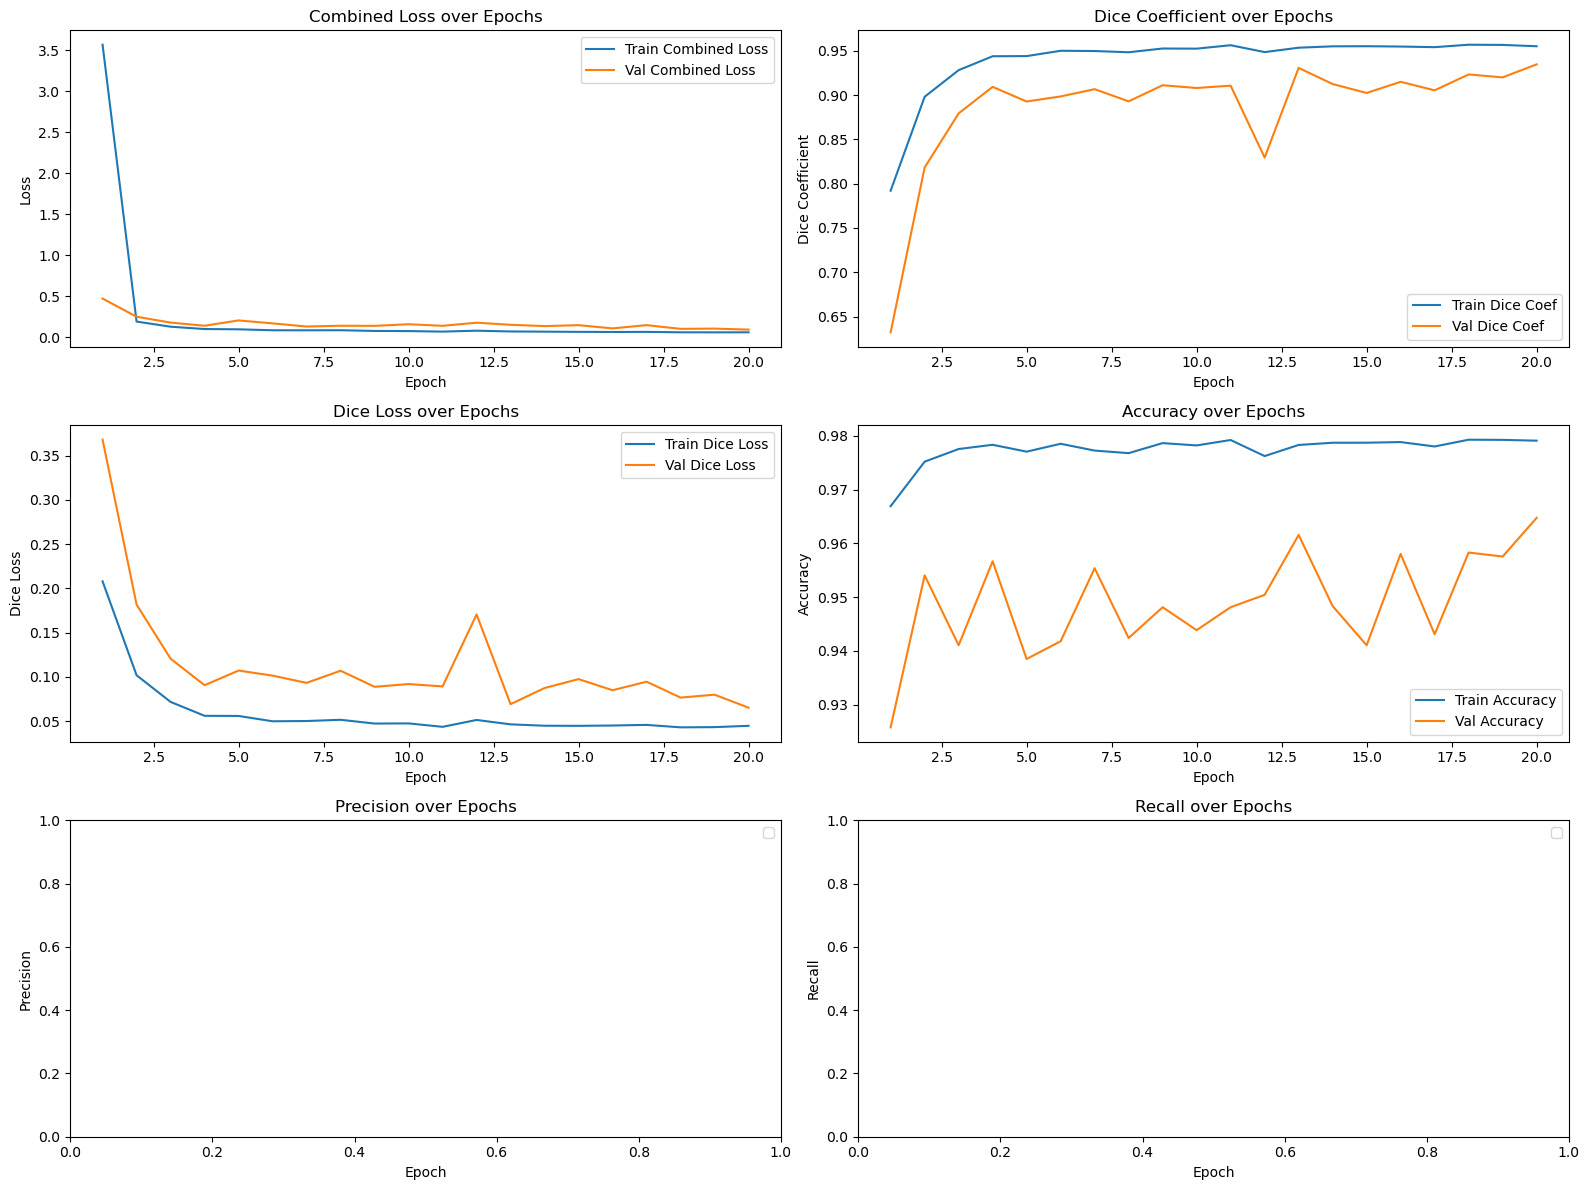


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_01.1_2025-03-06-14-48\Model_Data
31/31 [==============================] - 7s 222ms/step - loss: 0.1270 - accuracy: 0.9632 - precision_1: 0.9770 - recall_1: 0.9270 - dice_coef: 0.9457


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_01.1
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/d045395995874f37abce579875d4d6fa
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9669106602668762, 0.9792702794075012)
COMET INFO:     batch_accuracy [260]             : (0.5535423755645752, 0.9903287887573242)
COMET INFO:     batch_dice_coef [260]            : (0.2672349214553833, 0.9595769047737122)
COMET INFO:     batch_loss [260]                 

In [7]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.30, 0.20) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_01.1"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/fcb66351802b4e5d9cfb05686f26dd52



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

Elkton: 
Num of pairs: 11662
Num of pairs with 20.0% to 80.0% snow pixels: 1351
Num of pairs with 20.0% or less snow pixels: 8641
Num of pairs with 80.0% or more snow pixels: 1670
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 3069
Number of pairs with 20.0% or less snow pixels: 2454
Number of pairs with 80.0% or more snow pixels: 613
Selected 6136 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Total

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 191
Epoch 1/20
Batch 0: loss = 47.0835
Batch 1: loss = 44.3319/step - loss: 47.0835 - accuracy: 0.6540 - precision_2: 0.5216 - recall_2: 0.4705 - dice_coef: 0.4415
Batch 2: loss = 41.69462ms/step - loss: 44.3319 - accuracy: 0.7829 - precision_2: 0.6704 - recall_2: 0.6756 - dice_coef: 0.5070
Batch 3: loss = 39.18888ms/step - loss: 41.6946 - accuracy: 0.8379 - precision_2: 0.7516 - recall_2: 0.7699 - dice_coef: 0.5602
Batch 4: loss = 36.82733ms/step - loss: 39.1888 - accuracy: 0.8638 - precision_2: 0.7942 - recall_2: 0.8065 - dice_coef: 0.6014
Batch 5: loss = 34.60763ms/step - loss: 36.8273 - accuracy: 0.8826 - precision_2: 0.8193 - recall_2: 0.8288 - dice_coef: 0.6266
Batch 6: loss = 32.53354ms/step - loss: 34.6076 - accuracy: 0.8952 - precision_2: 0.8332 - recall_2: 0.8464 - dice_coef: 0.6465
Batch 7: loss = 30.61824ms/step - loss: 32.5335 - accuracy: 0.9044 - precision_2: 0.8402 - recall_2: 0.8596 - dice_coef: 0

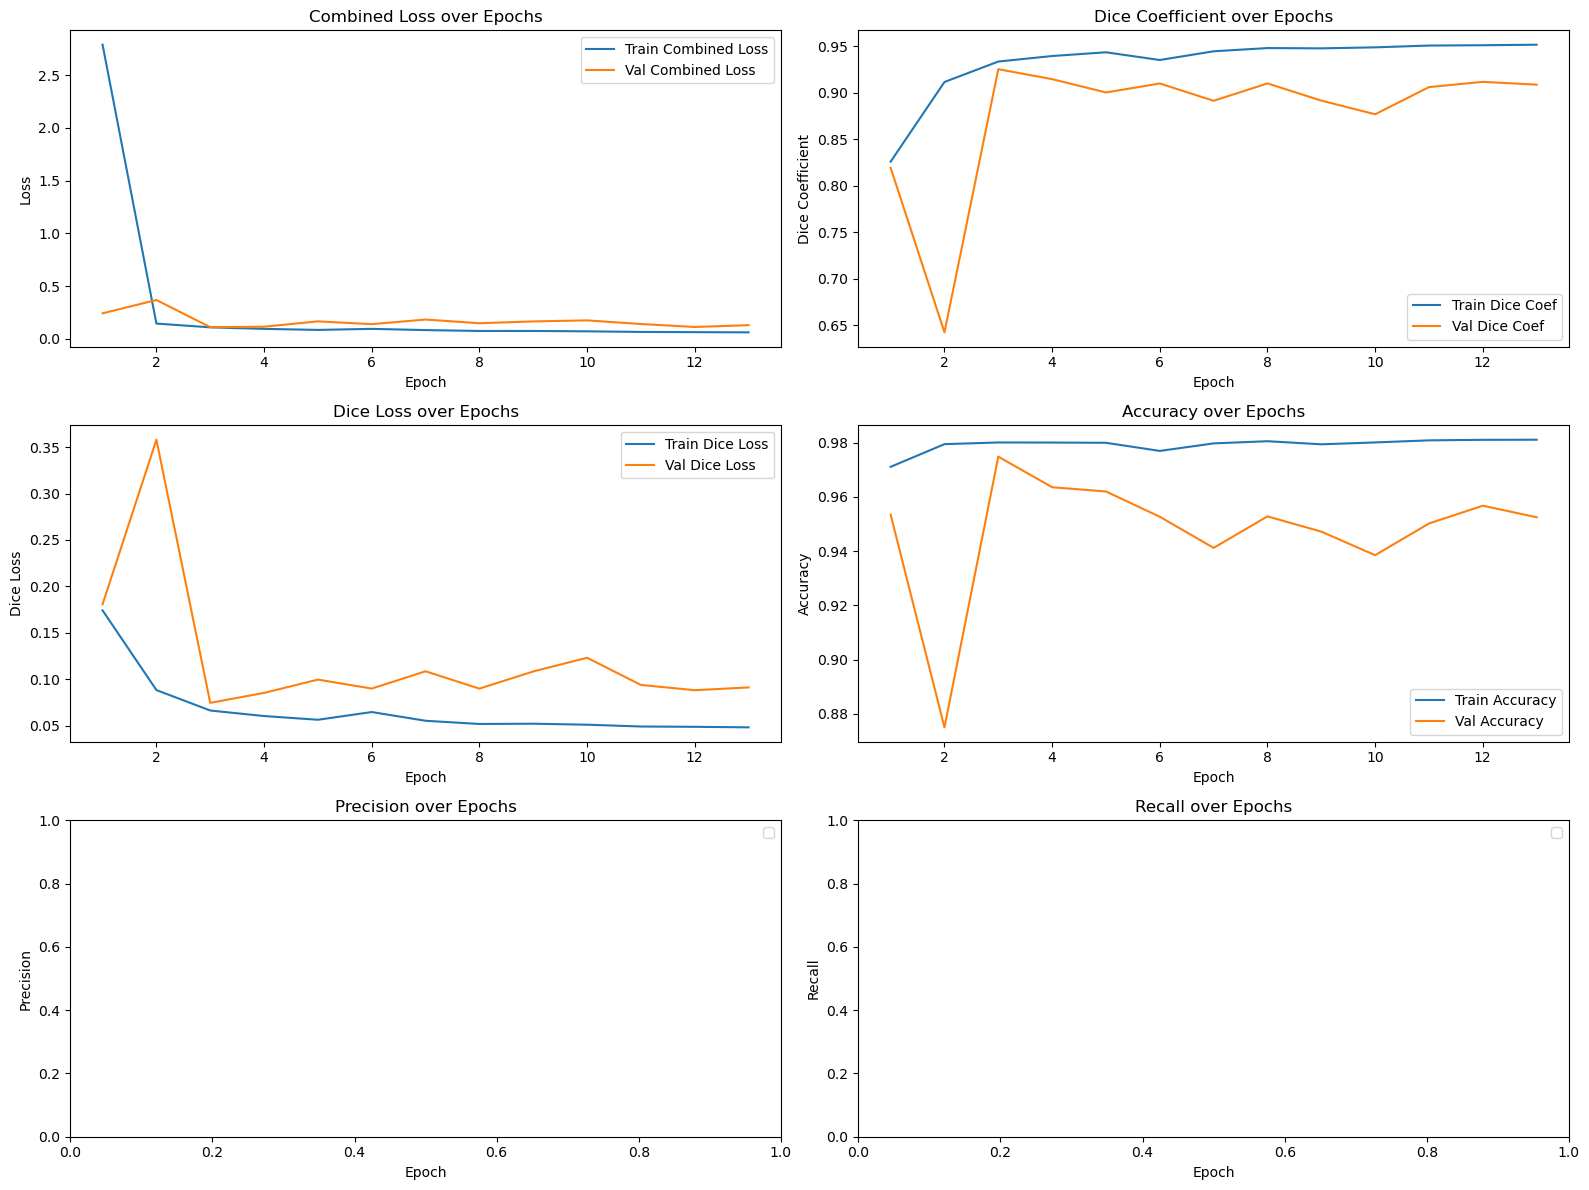


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_01.2_2025-03-06-15-16\Model_Data
33/33 [==============================] - 8s 229ms/step - loss: 0.1649 - accuracy: 0.9604 - precision_2: 0.9852 - recall_2: 0.8934 - dice_coef: 0.9114


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_01.2
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/fcb66351802b4e5d9cfb05686f26dd52
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [13]                    : (0.9710658192634583, 0.9810521602630615)
COMET INFO:     batch_accuracy [195]             : (0.653975248336792, 0.9832308292388916)
COMET INFO:     batch_dice_coef [195]            : (0.44145551323890686, 0.964113712310791)
COMET INFO:     batch_loss [195]                 :

In [8]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.40, 0.10) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_01.2"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/8d73281f116549b7912ca3d623031de3



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

Elkton: 
Num of pairs: 11662
Num of pairs with 20.0% to 80.0% snow pixels: 1351
Num of pairs with 20.0% or less snow pixels: 8641
Num of pairs with 80.0% or more snow pixels: 1670
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 3069
Number of pairs with 20.0% or less snow pixels: 2760
Number of pairs with 80.0% or more snow pixels: 306
Selected 6135 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Total

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Epoch 1/20
Batch 0: loss = 47.2017
Batch 1: loss = 44.3504/step - loss: 47.2017 - accuracy: 0.5476 - precision_3: 0.3428 - recall_3: 0.7738 - dice_coef: 0.3628
Batch 2: loss = 41.69660ms/step - loss: 44.3504 - accuracy: 0.6077 - precision_3: 0.3709 - recall_3: 0.8589 - dice_coef: 0.3825
Batch 3: loss = 39.14945ms/step - loss: 41.6966 - accuracy: 0.6530 - precision_3: 0.3678 - recall_3: 0.8843 - dice_coef: 0.3668
Batch 4: loss = 36.76856ms/step - loss: 39.1494 - accuracy: 0.7126 - precision_3: 0.4395 - recall_3: 0.9121 - dice_coef: 0.4079
Batch 5: loss = 34.51620ms/step - loss: 36.7685 - accuracy: 0.7501 - precision_3: 0.4660 - recall_3: 0.9240 - dice_coef: 0.4193
Batch 6: loss = 32.42914ms/step - loss: 34.5162 - accuracy: 0.7836 - precision_3: 0.5287 - recall_3: 0.9327 - dice_coef: 0.4575
Batch 7: loss = 30.51247ms/step - loss: 32.4291 - accuracy: 0.8057 - precision_3: 0.5566 - recall_3: 0.9386 - dice_coef: 0.4727
Batch 8: loss = 28.72568ms/step - loss: 30.5124 - accuracy: 0.8134 - pre

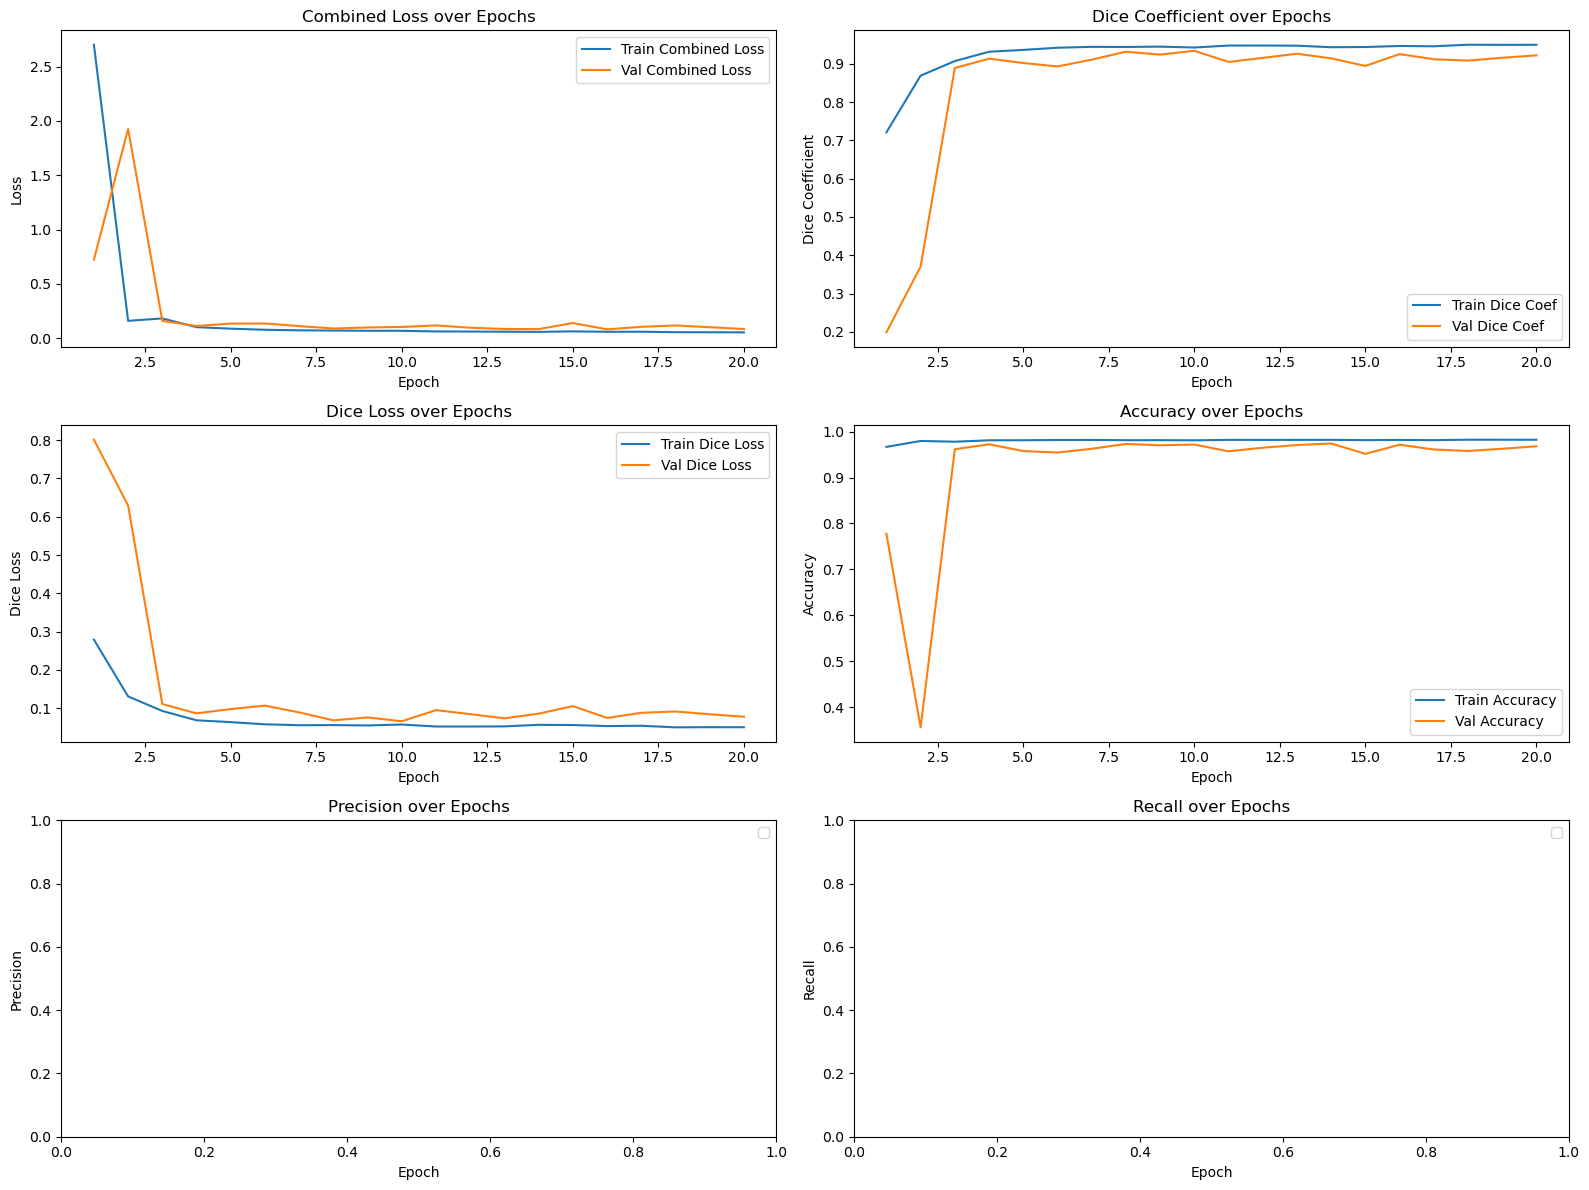


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_01.3_2025-03-06-15-37\Model_Data
33/33 [==============================] - 8s 228ms/step - loss: 0.1098 - accuracy: 0.9717 - precision_3: 0.9717 - recall_3: 0.9309 - dice_coef: 0.9363


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_01.3
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/8d73281f116549b7912ca3d623031de3
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9667049050331116, 0.982326090335846)
COMET INFO:     batch_accuracy [300]             : (0.5475659370422363, 0.9926347732543945)
COMET INFO:     batch_dice_coef [300]            : (0.36276185512542725, 0.9692544937133789)
COMET INFO:     batch_loss [300]                 

In [9]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.45, 0.05) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_01.3"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/7fdd51571df2445e9d2f0be3cd746c45



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

Elkton: 
Num of pairs: 11662
Num of pairs with 20.0% to 80.0% snow pixels: 1351
Num of pairs with 20.0% or less snow pixels: 8641
Num of pairs with 80.0% or more snow pixels: 1670
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 3069
Number of pairs with 20.0% or less snow pixels: 1227
Number of pairs with 80.0% or more snow pixels: 1718
Selected 6014 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Tota

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Epoch 1/20
Batch 0: loss = 47.2454
Batch 1: loss = 45.1076/step - loss: 47.2454 - accuracy: 0.3216 - precision_4: 0.2118 - recall_4: 0.4065 - dice_coef: 0.3594
Batch 2: loss = 42.85904ms/step - loss: 45.1076 - accuracy: 0.5121 - precision_4: 0.3529 - recall_4: 0.6571 - dice_coef: 0.4352
Batch 3: loss = 40.61425ms/step - loss: 42.8590 - accuracy: 0.6218 - precision_4: 0.4436 - recall_4: 0.7600 - dice_coef: 0.4969
Batch 4: loss = 38.45499ms/step - loss: 40.6142 - accuracy: 0.6978 - precision_4: 0.5454 - recall_4: 0.8114 - dice_coef: 0.5564
Batch 5: loss = 36.37067ms/step - loss: 38.4549 - accuracy: 0.7436 - precision_4: 0.5762 - recall_4: 0.8379 - dice_coef: 0.5724
Batch 6: loss = 34.37707ms/step - loss: 36.3706 - accuracy: 0.7757 - precision_4: 0.6126 - recall_4: 0.8614 - dice_coef: 0.5969
Batch 7: loss = 32.49173ms/step - loss: 34.3770 - accuracy: 0.8025 - precision_4: 0.6558 - recall_4: 0.8788 - dice_coef: 0.6248
Batch 8: loss = 30.72022ms/step - loss: 32.4917 - accuracy: 0.8211 - pre

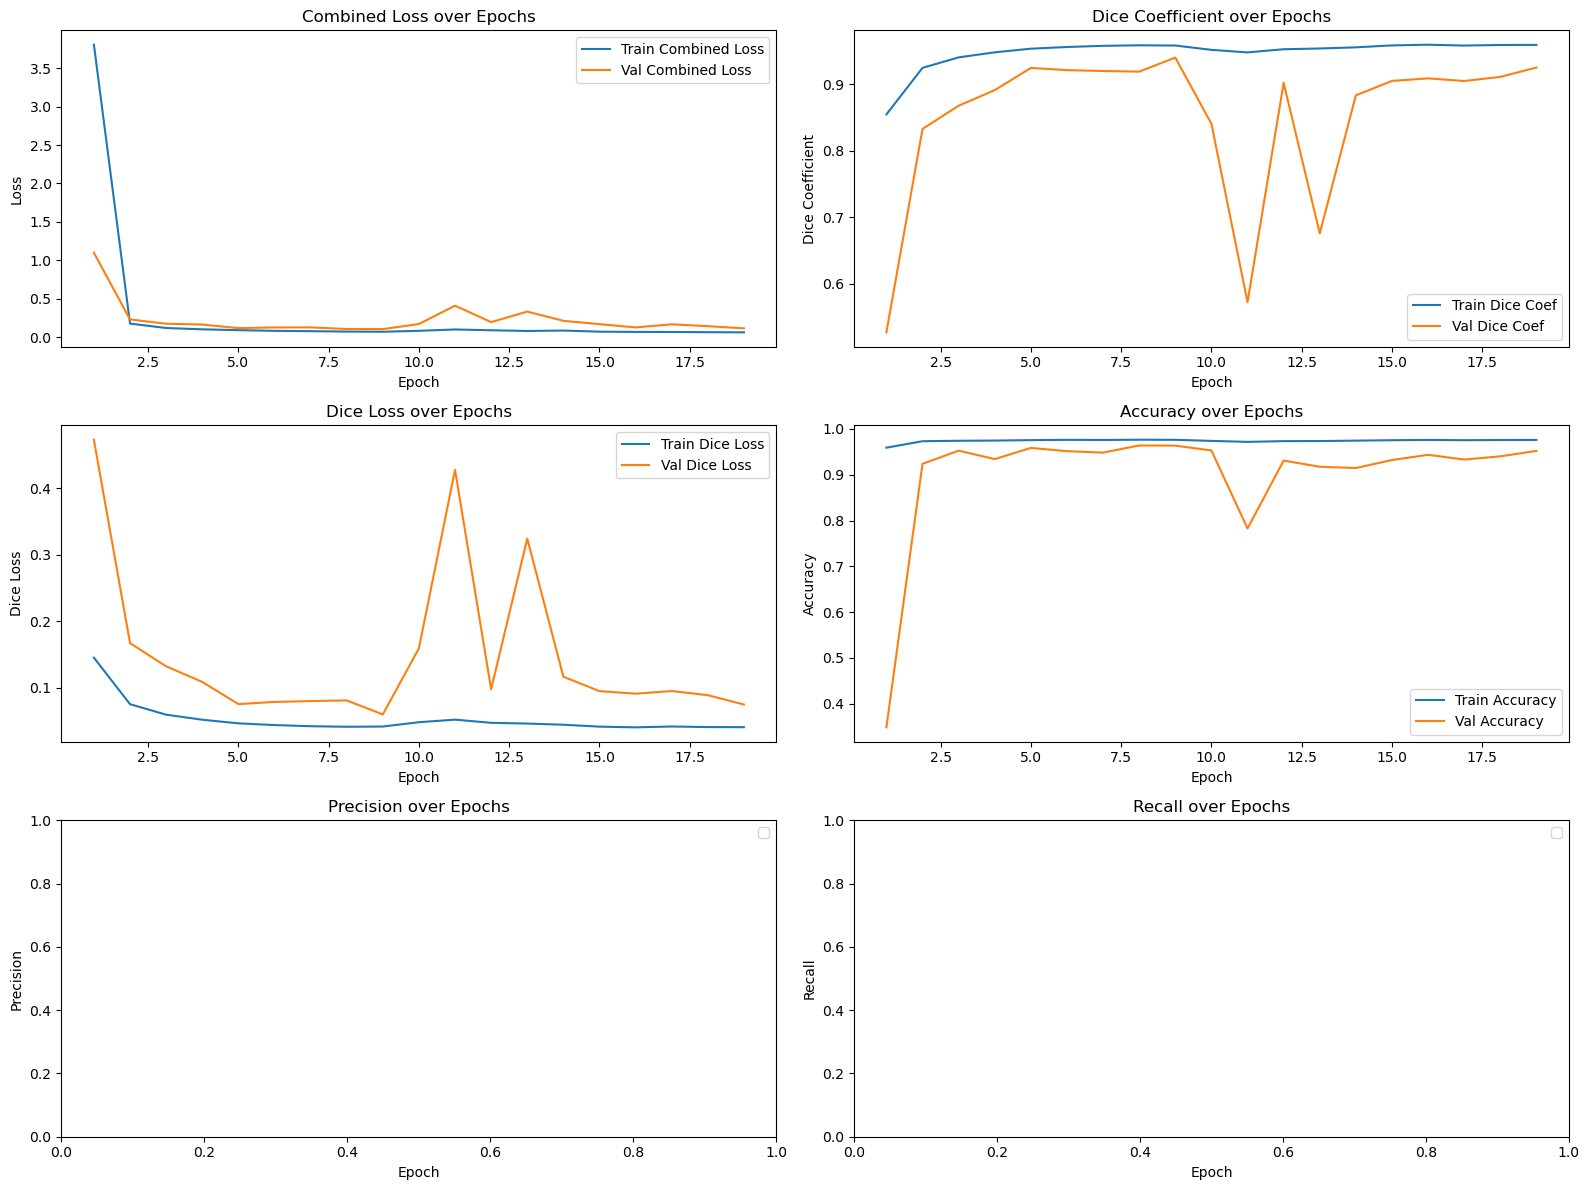


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_01.4_2025-03-06-16-08\Model_Data
28/28 [==============================] - 7s 219ms/step - loss: 0.1579 - accuracy: 0.9561 - precision_4: 0.9831 - recall_4: 0.9114 - dice_coef: 0.9383


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_01.4
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/7fdd51571df2445e9d2f0be3cd746c45
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [19]                    : (0.9591466784477234, 0.9765558838844299)
COMET INFO:     batch_accuracy [228]             : (0.321582555770874, 0.9829568862915039)
COMET INFO:     batch_dice_coef [228]            : (0.3594168722629547, 0.9628339409828186)
COMET INFO:     batch_loss [228]                 :

In [10]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.20, 0.30) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_01.4"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/86a99282bcc645b0b235145ad6134315



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

Elkton: 
Num of pairs: 11662
Num of pairs with 20.0% to 80.0% snow pixels: 1351
Num of pairs with 20.0% or less snow pixels: 8641
Num of pairs with 80.0% or more snow pixels: 1670
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 3069
Number of pairs with 20.0% or less snow pixels: 613
Number of pairs with 80.0% or more snow pixels: 2265
Selected 5947 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Total

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Epoch 1/20
Batch 0: loss = 47.2257
Batch 1: loss = 44.5347/step - loss: 47.2257 - accuracy: 0.4759 - precision_5: 0.1240 - recall_5: 0.0923 - dice_coef: 0.3157
Batch 2: loss = 41.95415ms/step - loss: 44.5347 - accuracy: 0.6232 - precision_5: 0.5161 - recall_5: 0.3938 - dice_coef: 0.4313
Batch 3: loss = 39.48976ms/step - loss: 41.9541 - accuracy: 0.7280 - precision_5: 0.6551 - recall_5: 0.5632 - dice_coef: 0.4958
Batch 4: loss = 37.15553ms/step - loss: 39.4897 - accuracy: 0.7819 - precision_5: 0.7488 - recall_5: 0.6679 - dice_coef: 0.5512
Batch 5: loss = 34.96199ms/step - loss: 37.1555 - accuracy: 0.8132 - precision_5: 0.7829 - recall_5: 0.7228 - dice_coef: 0.5850
Batch 6: loss = 32.89326ms/step - loss: 34.9619 - accuracy: 0.8234 - precision_5: 0.8261 - recall_5: 0.7442 - dice_coef: 0.6125
Batch 7: loss = 30.95627ms/step - loss: 32.8932 - accuracy: 0.8418 - precision_5: 0.8554 - recall_5: 0.7797 - dice_coef: 0.6389
Batch 8: loss = 29.15533ms/step - loss: 30.9562 - accuracy: 0.8581 - pre

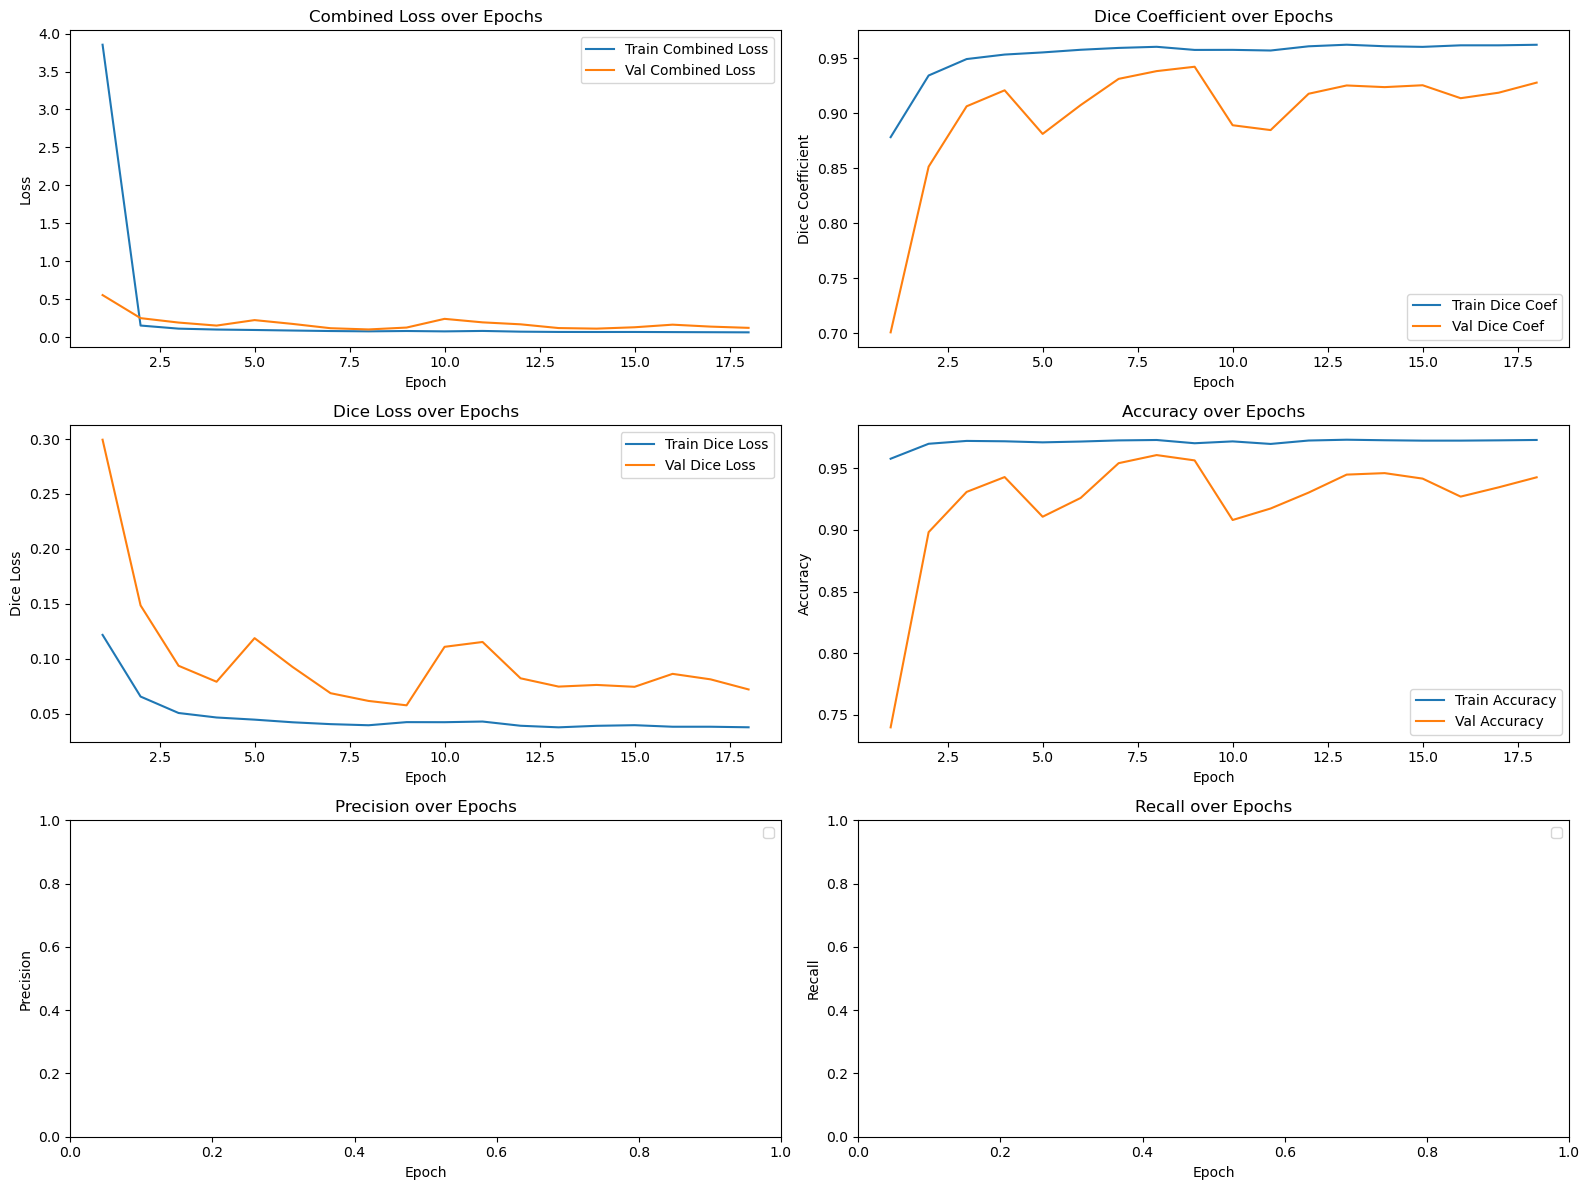


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_01.5_2025-03-06-16-32\Model_Data
25/25 [==============================] - 6s 230ms/step - loss: 0.2368 - accuracy: 0.9186 - precision_5: 0.9852 - recall_5: 0.8360 - dice_coef: 0.8923


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_01.5
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/86a99282bcc645b0b235145ad6134315
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [18]                    : (0.9577207565307617, 0.9731333255767822)
COMET INFO:     batch_accuracy [198]             : (0.4759373664855957, 0.980309247970581)
COMET INFO:     batch_dice_coef [198]            : (0.31573984026908875, 0.9666526913642883)
COMET INFO:     batch_loss [198]                 

In [11]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.10, 0.40) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_01.5"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/94c3ab0d1a4b4afc99e5d61dec7753d7



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 20.0% to 80.0% snow pixels: 1383
Num of pairs with 20.0% or less snow pixels: 13390
Num of pairs with 80.0% or more snow pixels: 1672

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 20.0% to 80.0% snow pixels: 335
Num of pairs with 20.0% or less snow pixels: 6143
Num of pairs with 80.0% or more snow pixels: 79

Elkton: 
Num of pairs: 11662
Num of pairs with 20.0% to 80.0% snow pixels: 1351
Num of pairs with 20.0% or less snow pixels: 8641
Num of pairs with 80.0% or more snow pixels: 1670
Total tiles breakdown
Number of pairs with 20.0% to 80.0% snow pixels: 3069
Number of pairs with 20.0% or less snow pixels: 306
Number of pairs with 80.0% or more snow pixels: 2538
Selected 5913 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 20.0% to 80.0% snow pixels: 1574
Num of pairs with 20.0% or less snow pixels: 8991
Num of pairs with 80.0% or more snow pixels: 1624
Total

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Epoch 1/20
Batch 0: loss = 47.1565
Batch 1: loss = 44.34905s/step - loss: 47.1565 - accuracy: 0.3511 - precision: 0.2006 - recall: 0.0744 - dice_coef: 0.4467
Batch 2: loss = 41.659540ms/step - loss: 44.3490 - accuracy: 0.4886 - precision: 0.5071 - recall: 0.2418 - dice_coef: 0.4915
Batch 3: loss = 39.113614ms/step - loss: 41.6595 - accuracy: 0.5975 - precision: 0.7198 - recall: 0.4262 - dice_coef: 0.5399
Batch 4: loss = 36.712443ms/step - loss: 39.1136 - accuracy: 0.6834 - precision: 0.7748 - recall: 0.5279 - dice_coef: 0.5592
Batch 5: loss = 34.459407ms/step - loss: 36.7124 - accuracy: 0.7316 - precision: 0.8214 - recall: 0.6090 - dice_coef: 0.5887
Batch 6: loss = 32.363395ms/step - loss: 34.4594 - accuracy: 0.7667 - precision: 0.8523 - recall: 0.6675 - dice_coef: 0.6163
Batch 7: loss = 30.414465ms/step - loss: 32.3633 - accuracy: 0.7896 - precision: 0.8788 - recall: 0.7125 - dice_coef: 0.6383
Batch 8: loss = 28.601676ms/step - loss: 30.4144 - accuracy: 0.8072 - precision: 0.8806 - re

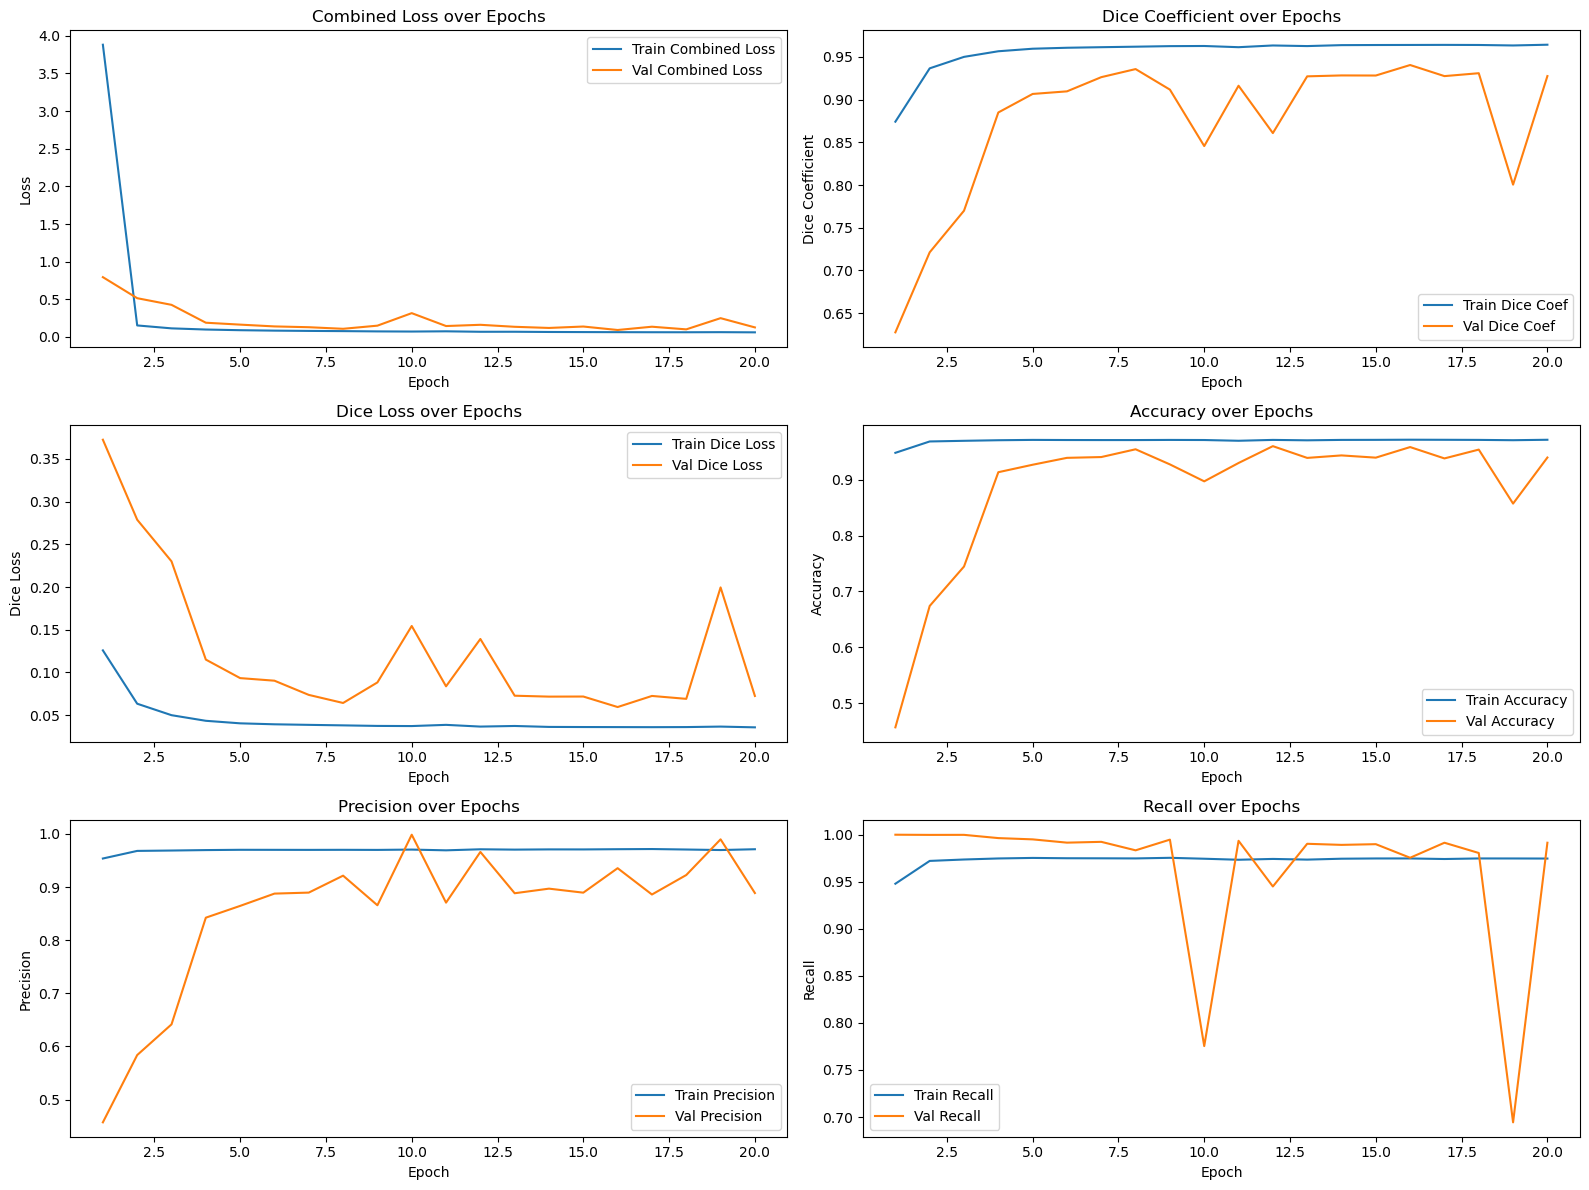


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_01.6_2025-03-06-17-49\Model_Data
23/23 [==============================] - 6s 242ms/step - loss: 0.1216 - accuracy: 0.9541 - precision: 0.9713 - recall: 0.9352 - dice_coef: 0.9446


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_01.6
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/94c3ab0d1a4b4afc99e5d61dec7753d7
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                  : (0.9478123784065247, 0.9712409973144531)
COMET INFO:     batch_accuracy [200]           : (0.35109686851501465, 0.9762129783630371)
COMET INFO:     batch_dice_coef [200]          : (0.4467308521270752, 0.9692666530609131)
COMET INFO:     batch_loss [200]               : (0.05554651468992233, 47.156490325927734)
COMET INFO:     batch_precision [200]          : (0.20063234865665436, 0.9776387810707092)
COMET INFO:     batch_recal

In [6]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.05, 0.45) 
snow_vs_notsnow_ratio_distribution=(.8, .2)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_01.6"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/423d721aae45438c94320140e4071303



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 10.0% to 90.0% snow pixels: 1942
Num of pairs with 10.0% or less snow pixels: 13081
Num of pairs with 90.0% or more snow pixels: 1422

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 10.0% to 90.0% snow pixels: 527
Num of pairs with 10.0% or less snow pixels: 5971
Num of pairs with 90.0% or more snow pixels: 59

Elkton: 
Num of pairs: 11662
Num of pairs with 10.0% to 90.0% snow pixels: 1952
Num of pairs with 10.0% or less snow pixels: 8259
Num of pairs with 90.0% or more snow pixels: 1451
Total tiles breakdown
Number of pairs with 10.0% to 90.0% snow pixels: 4421
Number of pairs with 10.0% or less snow pixels: 2210
Number of pairs with 90.0% or more snow pixels: 2006
Selected 8637 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 10.0% to 90.0% snow pixels: 2244
Num of pairs with 10.0% or less snow pixels: 8561
Num of pairs with 90.0% or more snow pixels: 1384
Tota

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 269
Epoch 1/20
Batch 0: loss = 47.1487
Batch 1: loss = 44.7753/step - loss: 47.1487 - accuracy: 0.5407 - precision_1: 0.3329 - recall_1: 0.8049 - dice_coef: 0.4017
Batch 2: loss = 42.42843ms/step - loss: 44.7753 - accuracy: 0.7087 - precision_1: 0.5500 - recall_1: 0.8953 - dice_coef: 0.5460
Batch 3: loss = 40.13090ms/step - loss: 42.4284 - accuracy: 0.7819 - precision_1: 0.6281 - recall_1: 0.9184 - dice_coef: 0.6006
Batch 4: loss = 37.94976ms/step - loss: 40.1309 - accuracy: 0.8203 - precision_1: 0.6933 - recall_1: 0.9267 - dice_coef: 0.6458
Batch 5: loss = 35.83809ms/step - loss: 37.9497 - accuracy: 0.8395 - precision_1: 0.6987 - recall_1: 0.9332 - dice_coef: 0.6408
Batch 6: loss = 33.83191ms/step - loss: 35.8380 - accuracy: 0.8588 - precision_1: 0.7248 - recall_1: 0.9392 - dice_coef: 0.6611
Batch 7: loss = 31.93514ms/step - loss: 33.8319 - accuracy: 0.8729 - precision_1: 0.7487 - recall_1: 0.9413 - dice_coef: 0

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:242: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,0].legend()
C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:252: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,1].legend()


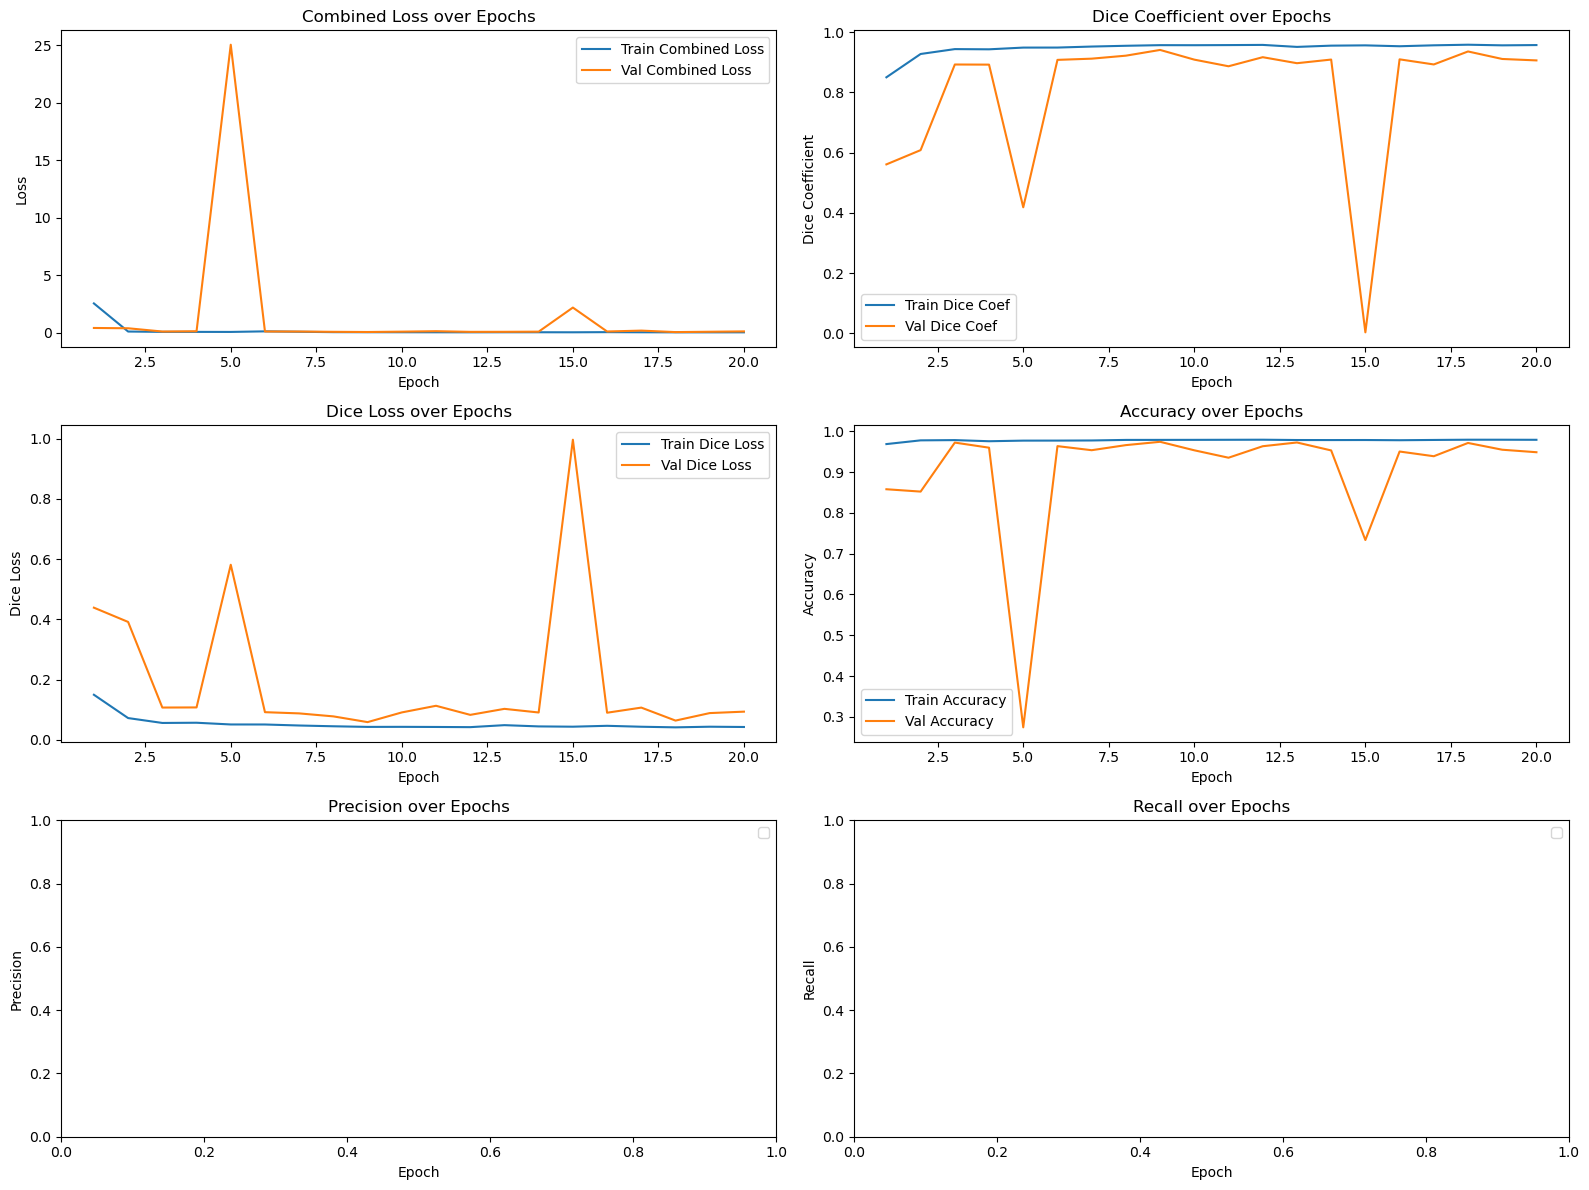


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_02_2025-03-06-18-14\Model_Data
40/40 [==============================] - 9s 229ms/step - loss: 0.1121 - accuracy: 0.9631 - precision_1: 0.9411 - recall_1: 0.9485 - dice_coef: 0.9376


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_02
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/423d721aae45438c94320140e4071303
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9689273238182068, 0.9796391725540161)
COMET INFO:     batch_accuracy [360]             : (0.5407009124755859, 0.985785961151123)
COMET INFO:     batch_dice_coef [360]            : (0.40172749757766724, 0.9762231707572937)
COMET INFO:     batch_loss [360]                 : 

In [7]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.25, 0.25) 
snow_vs_notsnow_ratio_distribution=(.9, .1)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_02"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/2bac050491a8410886ee73f6660218a9



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 10.0% to 90.0% snow pixels: 1942
Num of pairs with 10.0% or less snow pixels: 13081
Num of pairs with 90.0% or more snow pixels: 1422

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 10.0% to 90.0% snow pixels: 527
Num of pairs with 10.0% or less snow pixels: 5971
Num of pairs with 90.0% or more snow pixels: 59

Elkton: 
Num of pairs: 11662
Num of pairs with 10.0% to 90.0% snow pixels: 1952
Num of pairs with 10.0% or less snow pixels: 8259
Num of pairs with 90.0% or more snow pixels: 1451
Total tiles breakdown
Number of pairs with 10.0% to 90.0% snow pixels: 4421
Number of pairs with 10.0% or less snow pixels: 2652
Number of pairs with 90.0% or more snow pixels: 1615
Selected 8688 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 10.0% to 90.0% snow pixels: 2244
Num of pairs with 10.0% or less snow pixels: 8561
Num of pairs with 90.0% or more snow pixels: 1384
Tota

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 271
Epoch 1/20
Batch 0: loss = 47.0701
Batch 1: loss = 44.7643/step - loss: 47.0701 - accuracy: 0.6835 - precision_2: 0.5690 - recall_2: 0.5546 - dice_coef: 0.4615
Batch 2: loss = 42.49679ms/step - loss: 44.7643 - accuracy: 0.8029 - precision_2: 0.7323 - recall_2: 0.7606 - dice_coef: 0.5535
Batch 3: loss = 40.18793ms/step - loss: 42.4967 - accuracy: 0.7872 - precision_2: 0.6234 - recall_2: 0.7958 - dice_coef: 0.5157
Batch 4: loss = 37.98997ms/step - loss: 40.1879 - accuracy: 0.8285 - precision_2: 0.6883 - recall_2: 0.8445 - dice_coef: 0.5609
Batch 5: loss = 35.86320ms/step - loss: 37.9899 - accuracy: 0.8306 - precision_2: 0.6647 - recall_2: 0.8648 - dice_coef: 0.5602
Batch 6: loss = 33.8413
Batch 7: loss = 31.95061ms/step - loss: 33.8413 - accuracy: 0.8661 - precision_2: 0.7261 - recall_2: 0.8985 - dice_coef: 0.6120
Batch 8: loss = 30.16213ms/step - loss: 31.9506 - accuracy: 0.8731 - precision_2: 0.7266 - recall_

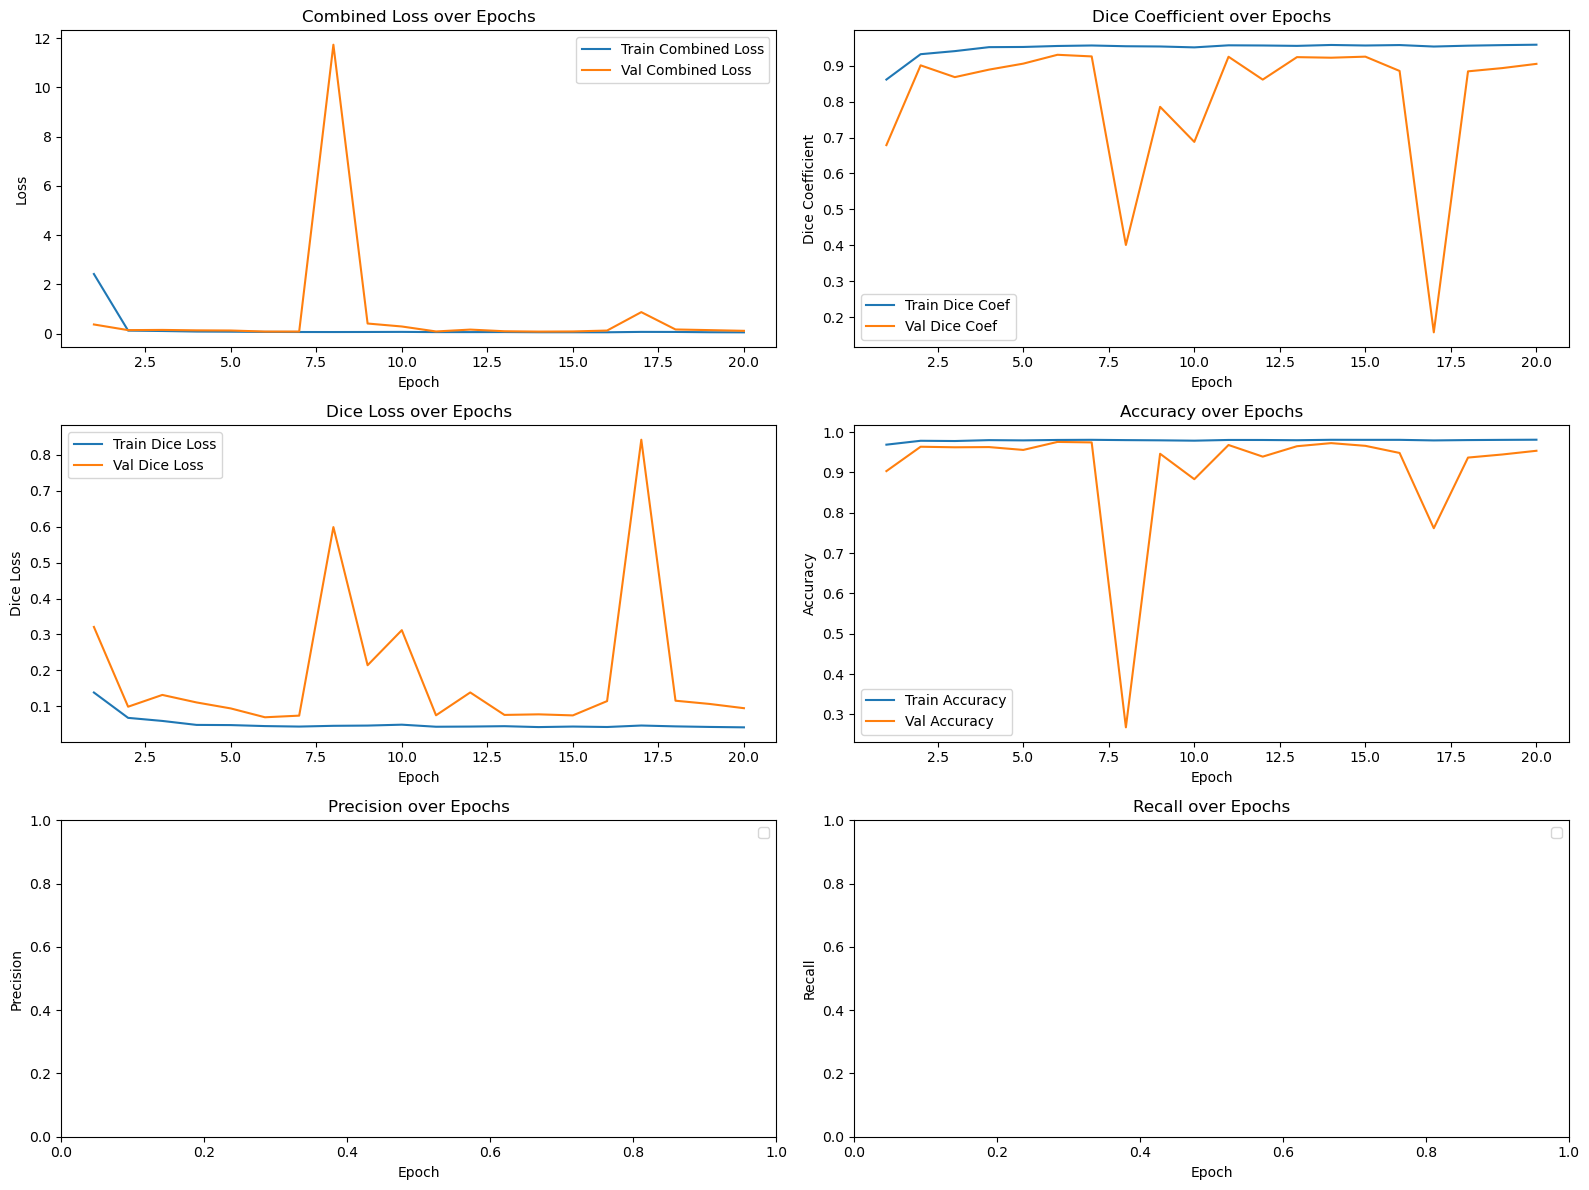


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_02.1_2025-03-06-18-49\Model_Data
42/42 [==============================] - 10s 220ms/step - loss: 0.1152 - accuracy: 0.9667 - precision_2: 0.9523 - recall_2: 0.9428 - dice_coef: 0.9392


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_02.1
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/2bac050491a8410886ee73f6660218a9
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9687886834144592, 0.981054961681366)
COMET INFO:     batch_accuracy [380]             : (0.6834981441497803, 0.9912221431732178)
COMET INFO:     batch_dice_coef [380]            : (0.46153178811073303, 0.9836053252220154)
COMET INFO:     batch_loss [380]                 

In [8]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.30, 0.20) 
snow_vs_notsnow_ratio_distribution=(.9, .1)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_02.1"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.40, 0.10) 
snow_vs_notsnow_ratio_distribution=(.9, .1)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_02.2"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/1c015d4c7a764a438d385555bfbfc535



---------Training Tiles---------


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information



DeerCreekTrail: 
Num of pairs: 16445
Num of pairs with 10.0% to 90.0% snow pixels: 1942
Num of pairs with 10.0% or less snow pixels: 13081
Num of pairs with 90.0% or more snow pixels: 1422

EastRiverTrail: 
Num of pairs: 6557
Num of pairs with 10.0% to 90.0% snow pixels: 527
Num of pairs with 10.0% or less snow pixels: 5971
Num of pairs with 90.0% or more snow pixels: 59

Elkton: 
Num of pairs: 11662
Num of pairs with 10.0% to 90.0% snow pixels: 1952
Num of pairs with 10.0% or less snow pixels: 8259
Num of pairs with 90.0% or more snow pixels: 1451
Total tiles breakdown
Number of pairs with 10.0% to 90.0% snow pixels: 4421
Number of pairs with 10.0% or less snow pixels: 3535
Number of pairs with 90.0% or more snow pixels: 837
Selected 8793 valid (img, msk) pairs

---------Validation Tiles---------

StrandHill: 
Num of pairs: 12189
Num of pairs with 10.0% to 90.0% snow pixels: 2244
Num of pairs with 10.0% or less snow pixels: 8561
Num of pairs with 90.0% or more snow pixels: 1384
Total

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Epoch 1/20
Batch 0: loss = 47.1901
Batch 1: loss = 44.7744/step - loss: 47.1901 - accuracy: 0.4899 - precision_3: 0.1269 - recall_3: 0.1567 - dice_coef: 0.3022
Batch 2: loss = 42.27303ms/step - loss: 44.7744 - accuracy: 0.5717 - precision_3: 0.1399 - recall_3: 0.2648 - dice_coef: 0.2392
Batch 3: loss = 39.87710ms/step - loss: 42.2730 - accuracy: 0.6689 - precision_3: 0.3383 - recall_3: 0.5579 - dice_coef: 0.3154
Batch 4: loss = 37.57942ms/step - loss: 39.8771 - accuracy: 0.7230 - precision_3: 0.4125 - recall_3: 0.6578 - dice_coef: 0.3495
Batch 5: loss = 35.41667ms/step - loss: 37.5794 - accuracy: 0.7613 - precision_3: 0.4907 - recall_3: 0.7318 - dice_coef: 0.3939
Batch 6: loss = 33.38267ms/step - loss: 35.4166 - accuracy: 0.7870 - precision_3: 0.5210 - recall_3: 0.7654 - dice_coef: 0.4106
Batch 7: loss = 31.48057ms/step - loss: 33.3826 - accuracy: 0.8038 - precision_3: 0.5340 - recall_3: 0.7880 - dice_coef: 0.4191
Batch 8: loss = 29.68547ms/step - loss: 31.4805 - accuracy: 0.8135 - pre

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.45, 0.05) 
snow_vs_notsnow_ratio_distribution=(.9, .1)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_02.3"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.20, 0.30) 
snow_vs_notsnow_ratio_distribution=(.9, .1)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_02.4"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.10, 0.40) 
snow_vs_notsnow_ratio_distribution=(.9, .1)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_02.5"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.05, 0.45) 
snow_vs_notsnow_ratio_distribution=(.9, .1)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_02.6"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.25, 0.25) 
snow_vs_notsnow_ratio_distribution=(.95, .05)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_03"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.30, 0.20) 
snow_vs_notsnow_ratio_distribution=(.95, .05)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_03.1"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.40, 0.10) 
snow_vs_notsnow_ratio_distribution=(.95, .05)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_03.2"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.45, 0.05) 
snow_vs_notsnow_ratio_distribution=(.95, .05)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_03.3"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.20, 0.30) 
snow_vs_notsnow_ratio_distribution=(.95, .05)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_03.4"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.10, 0.40) 
snow_vs_notsnow_ratio_distribution=(.95, .05)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_03.5"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )

In [ ]:
#["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
training_sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton"] 
validation_sites = ["StrandHill"]
testing_sites = ["VirginiaBasin"]
max_tiles_per_training_sites = 100000
max_tiles_per_validation_sites = 100000
max_tiles_per_testing_sites = 100000

mid_low_high_ratio_distribution=(0.5, 0.05, 0.45) 
snow_vs_notsnow_ratio_distribution=(.95, .05)

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_03.6"

# Run training
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    training_sites = training_sites,               # list of site names for training (e.g., ["DeerCreekTrail", "EastRiverTrail"])
    validation_sites = validation_sites,           # list of site names for in-distribution validation
    testing_sites =testing_sites,                  # list of site names for testing (unseen sites)   
    max_tiles_per_training_sites=max_tiles_per_training_sites,                   # maximum number of training tile pairs per site
    max_tiles_per_validation_sites=max_tiles_per_validation_sites,               # maximum number of validation tile pairs per site
    max_tiles_per_testing_sites=max_tiles_per_testing_sites,                     # maximum number of testing tile pairs per site
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
    )